## 3. Data Cleaning and Preprocessing

This notebook starts from `df_stage2a`, which already has:
- known bad time windows removed,
- pre-commissioning period removed,
- inverter disturbance window removed,
- late high-missingness period after September 2023 removed.

This notebook will handle:
- physical sensor cleaning,
- target cleaning,
- suspicious daytime zero handling,
- column selection,
- final modeling dataset preparation.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PROCESSED = ROOT / "data_processed"
RESULTS_DIR = ROOT / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

stage2a_pkl_path = DATA_PROCESSED / "df_stage2a_selected_modeling_window.pkl"
stage2a_csv_path = DATA_PROCESSED / "df_stage2a_selected_modeling_window.csv.gz"

if stage2a_pkl_path.exists():
    df_stage2a = pd.read_pickle(stage2a_pkl_path)
    print("Loaded df_stage2a from pickle.")
elif stage2a_csv_path.exists():
    df_stage2a = pd.read_csv(stage2a_csv_path, parse_dates=["timestamp"])
    print("Loaded df_stage2a from compressed CSV.")
else:
    raise FileNotFoundError("df_stage2a file not found in data_processed.")

df_stage2a["timestamp"] = pd.to_datetime(df_stage2a["timestamp"])
df_stage2a = df_stage2a.sort_values("timestamp").reset_index(drop=True)

print("Shape:", df_stage2a.shape)
print("Timestamp range:", df_stage2a["timestamp"].min(), "to", df_stage2a["timestamp"].max())
print("Active_Power missing:", df_stage2a["Active_Power"].isna().sum())
print("Active_Power coverage %:", round(df_stage2a["Active_Power"].notna().mean() * 100, 3))

Loaded df_stage2a from pickle.
Shape: (1495674, 14)
Timestamp range: 2009-01-16 00:00:00 to 2023-09-30 23:55:00
Active_Power missing: 640
Active_Power coverage %: 99.957


In [4]:
df_stage2a.head()

,timestamp,Active_Energy_Delivered_Received,Current_Phase_Average,Active_Power,Performance_Ratio,Wind_Speed,Weather_Temperature_Celsius,Weather_Relative_Humidity,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Radiation_Global_Tilted,Radiation_Diffuse_Tilted
0,2009-01-16 00:00:00,1761.0,0.3,0.0,NaN,3.417393,31.377642,26.503176,3.496551,0.818934,131.678650,0.0,NaN,NaN
1,2009-01-16 00:05:00,1761.0,0.3,0.0,NaN,2.681585,31.226942,26.779793,4.081000,1.370346,132.640137,0.0,NaN,NaN
2,2009-01-16 00:10:00,1761.0,0.3,0.0,NaN,2.793774,31.022598,27.137878,4.441686,1.780353,142.569473,0.0,NaN,NaN
3,2009-01-16 00:15:00,1761.0,0.3,0.0,NaN,3.011533,30.966803,27.247910,3.952593,1.219217,141.452988,0.0,NaN,NaN
4,2009-01-16 00:20:00,1761.0,0.3,0.0,NaN,2.325212,30.809612,27.495045,4.300272,1.527501,146.803833,0.0,NaN,NaN


### **1. Pre-processing Stage 2B — Audit selected modeling window before physical cleaning**

In [6]:
df_work = df_stage2a.copy()

df_work["timestamp"] = pd.to_datetime(df_work["timestamp"])
df_work = df_work.sort_values("timestamp").reset_index(drop=True)

print("df_work shape:", df_work.shape)
print("Timestamp range:", df_work["timestamp"].min(), "to", df_work["timestamp"].max())
print("Columns:", df_work.columns.tolist())

df_work shape: (1495674, 14)
Timestamp range: 2009-01-16 00:00:00 to 2023-09-30 23:55:00
Columns: ['timestamp', 'Active_Energy_Delivered_Received', 'Current_Phase_Average', 'Active_Power', 'Performance_Ratio', 'Wind_Speed', 'Weather_Temperature_Celsius', 'Weather_Relative_Humidity', 'Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation', 'Wind_Direction', 'Weather_Daily_Rainfall', 'Radiation_Global_Tilted', 'Radiation_Diffuse_Tilted']


In [7]:
#Core quality summary

suspicious_zero_ghi100 = (
    df_work["Active_Power"].eq(0) &
    df_work["Global_Horizontal_Radiation"].gt(100)
)

core_quality = pd.DataFrame([{
    "rows": len(df_work),
    "active_power_missing": int(df_work["Active_Power"].isna().sum()),
    "active_power_coverage_pct": round(df_work["Active_Power"].notna().mean() * 100, 3),
    "active_power_zero": int(df_work["Active_Power"].eq(0).sum()),
    "suspicious_zero_ghi100": int(suspicious_zero_ghi100.sum()),
    "active_power_negative": int((df_work["Active_Power"] < -0.01).sum()),
    "humidity_above_100": int((df_work["Weather_Relative_Humidity"] > 100).sum()),
    "temperature_below_minus10": int((df_work["Weather_Temperature_Celsius"] < -10).sum()),
    "ghi_above_1300": int((df_work["Global_Horizontal_Radiation"] > 1300).sum()),
    "diffuse_above_1300": int((df_work["Diffuse_Horizontal_Radiation"] > 1300).sum())
}])

display(core_quality)

,rows,active_power_missing,active_power_coverage_pct,active_power_zero,suspicious_zero_ghi100,active_power_negative,humidity_above_100,temperature_below_minus10,ghi_above_1300,diffuse_above_1300
0,1495674,640,99.957,760113,516,371,10471,3047,405,2


In [ ]:
#Feature availability by year

#This table will decide what we drop.

availability_by_year = (
    df_work
    .groupby(df_work["timestamp"].dt.year)
    .apply(lambda g: g.notna().mean() * 100)
    .round(1)
)

availability_by_year.index.name = "Year"

availability_cols = [
    "Active_Power",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Radiation_Global_Tilted",
    "Radiation_Diffuse_Tilted",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Weather_Daily_Rainfall",
    "Wind_Speed",
    "Wind_Direction",
    "Performance_Ratio",
    "Current_Phase_Average",
    "Active_Energy_Delivered_Received"
]

availability_cols = [c for c in availability_cols if c in availability_by_year.columns]

display(availability_by_year[availability_cols])

,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Radiation_Global_Tilted,Radiation_Diffuse_Tilted,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall,Wind_Speed,Wind_Direction,Performance_Ratio,Current_Phase_Average,Active_Energy_Delivered_Received
Year,,,,,,,,,,,,,
2009,100.0,100.0,100.0,0.0,0.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0
2010,100.0,100.0,100.0,0.0,0.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0
2011,100.0,99.5,99.5,0.0,0.0,99.5,99.5,99.5,99.5,99.5,0.0,100.0,100.0
2012,99.5,99.5,99.5,0.0,0.0,99.5,99.5,99.5,99.0,99.0,0.0,99.5,99.5
2013,100.0,100.0,100.0,58.2,58.2,100.0,100.0,100.0,98.4,98.4,0.0,100.0,100.0
2014,100.0,100.0,100.0,72.8,97.1,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0
2015,100.0,100.0,100.0,83.8,99.6,100.0,100.0,100.0,100.0,100.0,59.3,100.0,100.0
2016,100.0,100.0,100.0,98.7,98.7,100.0,100.0,100.0,80.5,100.0,100.0,100.0,100.0
2017,99.9,99.9,99.9,100.0,100.0,99.9,99.9,99.9,0.0,99.9,99.9,99.9,99.9


In [9]:
#Overall feature missingness and preliminary decision table

missing_pct = (df_work.isna().mean() * 100).round(2)

feature_notes = {
    "timestamp": "keep - time index",
    "Active_Power": "keep - target variable",
    "Global_Horizontal_Radiation": "likely keep - key irradiance feature / daylight audit",
    "Diffuse_Horizontal_Radiation": "likely keep - useful irradiance feature",
    "Weather_Temperature_Celsius": "likely keep after physical cleaning",
    "Weather_Relative_Humidity": "likely keep after physical cleaning",
    "Weather_Daily_Rainfall": "optional keep - low risk, may help weather regimes",
    "Radiation_Global_Tilted": "TBD - decide based on yearly availability",
    "Radiation_Diffuse_Tilted": "TBD - decide based on yearly availability",
    "Wind_Speed": "likely drop - high missingness / unavailable in later years",
    "Wind_Direction": "likely drop initially - weak PV relevance and paired with wind",
    "Performance_Ratio": "drop - derived metric / leakage risk",
    "Current_Phase_Average": "drop initially - electrically redundant with Active_Power",
    "Active_Energy_Delivered_Received": "drop initially - cumulative counter"
}

feature_audit = pd.DataFrame({
    "column": df_work.columns,
    "missing_pct": [missing_pct.get(c, np.nan) for c in df_work.columns],
    "note": [feature_notes.get(c, "review") for c in df_work.columns]
})

display(feature_audit.sort_values("missing_pct", ascending=False))

,column,missing_pct,note
5,Wind_Speed,45.64,likely drop - high missingness / unavailable i...
4,Performance_Ratio,44.75,drop - derived metric / leakage risk
12,Radiation_Global_Tilted,37.98,TBD - decide based on yearly availability
13,Radiation_Diffuse_Tilted,35.16,TBD - decide based on yearly availability
10,Wind_Direction,0.23,likely drop initially - weak PV relevance and ...
6,Weather_Temperature_Celsius,0.08,likely keep after physical cleaning
9,Diffuse_Horizontal_Radiation,0.08,likely keep - useful irradiance feature
8,Global_Horizontal_Radiation,0.08,likely keep - key irradiance feature / dayligh...
7,Weather_Relative_Humidity,0.08,likely keep after physical cleaning
11,Weather_Daily_Rainfall,0.08,"optional keep - low risk, may help weather reg..."


In [10]:
#Physical issue summary by year

physical_masks = {
    "active_power_negative": df_work["Active_Power"] < -0.01,
    "humidity_above_100": df_work["Weather_Relative_Humidity"] > 100,
    "temperature_below_minus10": df_work["Weather_Temperature_Celsius"] < -10,
    "temperature_above_60": df_work["Weather_Temperature_Celsius"] > 60,
    "ghi_above_1300": df_work["Global_Horizontal_Radiation"] > 1300,
    "ghi_negative": df_work["Global_Horizontal_Radiation"] < -5,
    "diffuse_above_1300": df_work["Diffuse_Horizontal_Radiation"] > 1300,
    "diffuse_negative": df_work["Diffuse_Horizontal_Radiation"] < -5,
}

physical_by_year = pd.DataFrame(index=sorted(df_work["timestamp"].dt.year.unique()))

for name, mask in physical_masks.items():
    yearly = (
        pd.Series(mask.to_numpy(), index=df_work["timestamp"])
        .resample("YE")
        .sum()
    )
    yearly.index = yearly.index.year
    physical_by_year[name] = yearly

physical_by_year = physical_by_year.fillna(0).astype(int)

display(physical_by_year)

,active_power_negative,humidity_above_100,temperature_below_minus10,temperature_above_60,ghi_above_1300,ghi_negative,diffuse_above_1300,diffuse_negative
2009,8,0,0,0,5,0,0,0
2010,10,0,0,0,11,0,0,0
2011,65,0,0,0,21,0,0,0
2012,57,0,0,0,37,0,2,0
2013,28,0,0,0,39,0,0,0
2014,64,363,0,0,37,0,0,0
2015,45,923,0,0,26,1,0,0
2016,38,2198,5,0,36,0,0,0
2017,56,273,0,0,16,0,0,0
2018,0,828,638,0,18,0,0,0


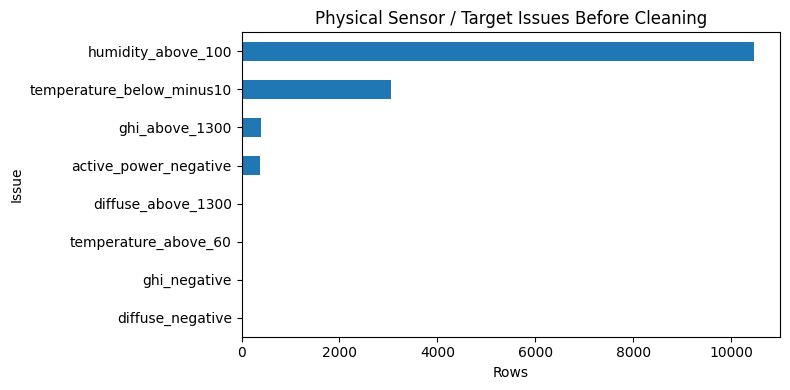

In [ ]:
#Simple plot of physical issue counts

physical_issue_counts = pd.Series({
    name: int(mask.sum())
    for name, mask in physical_masks.items()
}).sort_values()

plt.figure(figsize=(8, 4))
physical_issue_counts.plot(kind="barh")
plt.title("Physical Sensor / Target Issues Before Cleaning")
plt.xlabel("Rows")
plt.ylabel("Issue")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "physical_issue_counts_before_cleaning.png", dpi=150)
plt.show()

In [12]:
#Inspect example bad rows

inspect_cols = [
    "timestamp",
    "Active_Power",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Weather_Daily_Rainfall",
    "Current_Phase_Average"
]

inspect_cols = [c for c in inspect_cols if c in df_work.columns]

print("Examples: humidity > 100")
display(
    df_work.loc[df_work["Weather_Relative_Humidity"] > 100, inspect_cols]
    .sort_values("timestamp")
    .head(20)
)

print("Examples: temperature < -10")
display(
    df_work.loc[df_work["Weather_Temperature_Celsius"] < -10, inspect_cols]
    .sort_values("timestamp")
    .head(20)
)

print("Examples: GHI > 1300")
display(
    df_work.loc[df_work["Global_Horizontal_Radiation"] > 1300, inspect_cols]
    .sort_values("Global_Horizontal_Radiation", ascending=False)
    .head(20)
)

print("Examples: Active_Power < -0.01")
display(
    df_work.loc[df_work["Active_Power"] < -0.01, inspect_cols]
    .sort_values("Active_Power")
    .head(20)
)

Examples: humidity > 100


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall,Current_Phase_Average
549375,2014-04-08 13:00:00,0.759133,131.079147,129.061523,17.767786,100.024345,18.400000,3.314667
549376,2014-04-08 13:05:00,0.783600,144.223984,139.979385,17.988976,100.061989,19.199999,3.409334
549377,2014-04-08 13:10:00,0.919600,166.361481,161.750610,17.891016,100.042511,19.799999,3.937333
549378,2014-04-08 13:15:00,0.948666,174.868011,172.455414,18.046690,100.042107,20.599998,4.053333
549379,2014-04-08 13:20:00,1.145400,198.265259,194.363922,18.167809,100.021500,21.199999,4.814666
549857,2014-04-10 05:10:00,0.000000,2.287782,0.726067,15.963274,100.026428,0.200000,0.300000
549864,2014-04-10 05:45:00,0.000000,2.118324,0.565913,15.811460,100.126129,0.200000,0.300000
549865,2014-04-10 05:50:00,0.000000,2.476935,0.840269,15.841371,100.129349,0.200000,0.300000
549866,2014-04-10 05:55:00,0.000000,2.353863,0.705797,15.798725,100.064308,0.200000,0.300000
549867,2014-04-10 06:00:00,0.000000,2.264476,0.685662,15.776114,100.047630,0.200000,0.300000


Examples: temperature < -10


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall,Current_Phase_Average
785242,2016-07-05 13:00:00,2.349300,19.176310,10.254519,-39.987587,0.012150,0.0,9.940667
785243,2016-07-05 13:05:00,1.765767,18.776886,10.032946,-39.987572,0.012200,0.0,7.535668
785245,2016-07-05 13:15:00,1.699867,17.669197,9.294538,-39.987606,0.012162,0.0,7.265000
785246,2016-07-05 13:20:00,2.115100,19.010103,9.458185,-39.987576,0.012171,0.0,8.948999
785247,2016-07-05 13:25:00,2.669700,17.638815,9.012612,-39.987625,0.012130,0.0,11.280999
924999,2018-03-18 13:35:00,4.006033,15.623774,2.065990,-39.673271,0.298097,0.0,16.762999
925000,2018-03-18 13:40:00,3.943533,15.823484,2.068398,-38.560280,1.332587,0.0,16.500334
925001,2018-03-18 13:45:00,3.928467,16.158318,2.044201,-34.782188,4.960297,0.0,16.426998
925002,2018-03-18 13:50:00,3.992900,16.290895,2.044014,-30.253382,9.364765,0.0,16.716667
925003,2018-03-18 13:55:00,3.995267,16.368261,2.035644,-30.052586,9.506747,0.0,16.713333


Examples: GHI > 1300


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall,Current_Phase_Average
411167,2012-12-14 11:40:00,3.958667,2725.605957,2134.985107,39.817352,15.308847,0.0,16.298660
411166,2012-12-14 11:35:00,3.941733,2722.985352,2134.962158,40.110733,14.941099,0.0,16.210005
531521,2014-02-05 12:55:00,5.763267,1749.499634,644.790588,32.202217,27.176144,0.0,23.526005
531522,2014-02-05 13:00:00,5.792999,1688.195557,636.095398,32.175251,27.390186,0.0,23.666000
411168,2012-12-14 11:45:00,3.791533,1624.602417,867.346863,40.341038,14.947619,0.0,15.609999
531527,2014-02-05 13:25:00,5.474200,1568.782471,572.062317,32.957253,24.987930,0.0,22.428667
531526,2014-02-05 13:20:00,5.296533,1525.486450,499.856018,32.546383,25.793747,0.0,21.693998
1214768,2020-12-28 11:50:00,5.218566,1524.541870,518.826843,30.274279,28.156025,0.0,21.157001
531524,2014-02-05 13:10:00,5.185600,1513.661133,483.591400,32.329483,26.228199,0.0,21.249998
412318,2012-12-18 11:35:00,5.665866,1511.681519,595.954163,32.672222,32.148113,0.2,23.181335


Examples: Active_Power < -0.01


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall,Current_Phase_Average
881190,2017-06-03 18:05:00,-0.018800,8.811176,7.138417,14.885953,24.705606,0.0,1.462000
881191,2017-06-03 18:10:00,-0.018267,9.399652,7.532058,14.274584,25.660194,0.0,1.367000
265275,2011-07-26 18:15:00,-0.018133,11.195353,7.569714,16.847824,24.331905,0.0,1.546667
372657,2012-08-02 18:20:00,-0.017933,10.059052,6.541025,16.013010,13.952639,0.0,1.531333
264987,2011-07-25 18:15:00,-0.017800,9.822964,6.474363,17.400734,16.689409,0.0,1.444000
661177,2015-05-01 18:15:00,-0.017267,8.592024,6.848151,18.445021,16.212019,0.0,1.496667
572183,2014-06-26 18:05:00,-0.017200,9.045906,7.180493,15.812903,32.251118,0.0,1.438000
886950,2017-06-23 18:05:00,-0.016933,9.675652,7.991312,20.823772,23.924732,0.0,1.340667
587739,2014-08-19 18:25:00,-0.016933,6.837904,5.146753,15.795844,24.235844,0.0,1.404667
369776,2012-07-23 18:15:00,-0.016733,8.706488,5.384950,16.352587,27.913723,0.0,1.445667


In [13]:
#Remaining suspicious daytime zero runs

def summarize_flag_runs(dataframe, mask, label, max_rows=30):
    mask = pd.Series(mask, index=dataframe.index).fillna(False)
    groups = (mask != mask.shift()).cumsum()

    runs = (
        dataframe.loc[mask]
        .groupby(groups[mask])["timestamp"]
        .agg(start="min", end="max", rows="size")
        .reset_index(drop=True)
    )

    if len(runs) == 0:
        print(f"No runs found for: {label}")
        return pd.DataFrame()

    runs["duration"] = runs["end"] - runs["start"] + pd.Timedelta(minutes=5)
    runs = runs.sort_values(["rows", "start"], ascending=[False, True]).reset_index(drop=True)

    print(label)
    print("Total flagged rows:", int(mask.sum()))
    print("Number of separate runs:", len(runs))

    display(runs.head(max_rows))
    return runs


suspicious_zero_ghi100 = (
    df_work["Active_Power"].eq(0) &
    df_work["Global_Horizontal_Radiation"].gt(100)
)

suspicious_zero_runs = summarize_flag_runs(
    df_work,
    suspicious_zero_ghi100,
    "Remaining suspicious daytime zero runs: Active_Power = 0 and GHI > 100"
)

Remaining suspicious daytime zero runs: Active_Power = 0 and GHI > 100
Total flagged rows: 516
Number of separate runs: 83


,start,end,rows,duration
0,2010-08-26 07:35:00,2010-08-26 13:30:00,72,0 days 06:00:00
1,2016-01-30 14:40:00,2016-01-30 18:20:00,45,0 days 03:45:00
2,2010-10-28 14:30:00,2010-10-28 17:30:00,37,0 days 03:05:00
3,2010-11-09 07:00:00,2010-11-09 09:40:00,33,0 days 02:45:00
4,2013-07-02 11:25:00,2013-07-02 13:30:00,26,0 days 02:10:00
5,2009-12-20 08:15:00,2009-12-20 10:10:00,24,0 days 02:00:00
6,2010-08-13 08:40:00,2010-08-13 10:10:00,19,0 days 01:35:00
7,2013-02-23 17:15:00,2013-02-23 18:25:00,15,0 days 01:15:00
8,2010-02-09 11:25:00,2010-02-09 12:30:00,14,0 days 01:10:00
9,2010-03-10 12:20:00,2010-03-10 13:15:00,12,0 days 01:00:00


### Stage 2B — Physical cleaning of target and sensor variables

This stage applies physically valid corrections:
- tiny negative PV power values are clipped to zero,
- impossible PV power spikes are set to missing,
- impossible humidity, temperature, and irradiance readings are set to missing,
- suspicious daytime zero-power rows are marked as invalid target values.

No resampling or feature engineering is done yet.

In [15]:
#Create Stage 2B working copy

df_stage2b = df_stage2a.copy()

df_stage2b["timestamp"] = pd.to_datetime(df_stage2b["timestamp"])
df_stage2b = df_stage2b.sort_values("timestamp").reset_index(drop=True)

print("df_stage2b created from df_stage2a.")
print("Shape:", df_stage2b.shape)
print("Timestamp range:", df_stage2b["timestamp"].min(), "to", df_stage2b["timestamp"].max())

df_stage2b created from df_stage2a.
Shape: (1495674, 14)
Timestamp range: 2009-01-16 00:00:00 to 2023-09-30 23:55:00


In [16]:
#Define physical issue masks before cleaning

RATED_CAPACITY_KW = 5.25

masks_before_cleaning = {
    "active_power_missing": df_stage2b["Active_Power"].isna(),
    "active_power_negative": df_stage2b["Active_Power"] < 0,
    "active_power_above_5_8_kw": df_stage2b["Active_Power"] > 5.8,

    "suspicious_daytime_zero_ghi100": (
        df_stage2b["Active_Power"].eq(0) &
        df_stage2b["Global_Horizontal_Radiation"].gt(100)
    ),

    "humidity_above_100": df_stage2b["Weather_Relative_Humidity"] > 100,
    "humidity_below_0": df_stage2b["Weather_Relative_Humidity"] < 0,

    "temperature_below_minus10": df_stage2b["Weather_Temperature_Celsius"] < -10,
    "temperature_above_60": df_stage2b["Weather_Temperature_Celsius"] > 60,

    "ghi_below_0": df_stage2b["Global_Horizontal_Radiation"] < 0,
    "ghi_above_1300": df_stage2b["Global_Horizontal_Radiation"] > 1300,

    "dhi_below_0": df_stage2b["Diffuse_Horizontal_Radiation"] < 0,
    "dhi_above_1300": df_stage2b["Diffuse_Horizontal_Radiation"] > 1300,
}

issue_summary_before = pd.DataFrame([
    {
        "issue": name,
        "rows": int(mask.sum()),
        "pct": round(mask.mean() * 100, 5)
    }
    for name, mask in masks_before_cleaning.items()
]).sort_values("rows", ascending=False)

display(issue_summary_before)

,issue,rows,pct
4,humidity_above_100,10471,0.70009
1,active_power_negative,6284,0.42015
6,temperature_below_minus10,3047,0.20372
0,active_power_missing,640,0.04279
3,suspicious_daytime_zero_ghi100,516,0.03450
9,ghi_above_1300,405,0.02708
11,dhi_above_1300,2,0.00013
7,temperature_above_60,2,0.00013
2,active_power_above_5_8_kw,1,0.00007
8,ghi_below_0,1,0.00007


In [17]:
#Apply physical cleaning rules

#This cell modifies df_stage2b

# 1. Active_Power cleaning

# Tiny negative power values are physically impossible for PV generation.
# These are treated as meter/sensor noise and clipped to zero.
negative_power_mask = df_stage2b["Active_Power"] < 0
df_stage2b.loc[negative_power_mask, "Active_Power"] = 0

# Extremely high PV power above a safe physical threshold is treated as invalid.
high_power_mask = df_stage2b["Active_Power"] > 5.8
df_stage2b.loc[high_power_mask, "Active_Power"] = np.nan


# 2. Suspicious daytime zero power

# If GHI is clearly positive but PV output is exactly zero,
# this likely indicates outage, disconnection, or data-quality problem.
suspicious_zero_mask = (
    df_stage2b["Active_Power"].eq(0) &
    df_stage2b["Global_Horizontal_Radiation"].gt(100)
)

df_stage2b.loc[suspicious_zero_mask, "Active_Power"] = np.nan


# 3. Humidity cleaning

humidity_invalid_mask = (
    (df_stage2b["Weather_Relative_Humidity"] < 0) |
    (df_stage2b["Weather_Relative_Humidity"] > 100)
)

df_stage2b.loc[humidity_invalid_mask, "Weather_Relative_Humidity"] = np.nan


# 4. Temperature cleaning

temperature_invalid_mask = (
    (df_stage2b["Weather_Temperature_Celsius"] < -10) |
    (df_stage2b["Weather_Temperature_Celsius"] > 60)
)

df_stage2b.loc[temperature_invalid_mask, "Weather_Temperature_Celsius"] = np.nan


# 5. Irradiance cleaning

# Small negative irradiance values can happen as sensor noise around night.
# Set any negative irradiance to zero.
ghi_negative_mask = df_stage2b["Global_Horizontal_Radiation"] < 0
dhi_negative_mask = df_stage2b["Diffuse_Horizontal_Radiation"] < 0

df_stage2b.loc[ghi_negative_mask, "Global_Horizontal_Radiation"] = 0
df_stage2b.loc[dhi_negative_mask, "Diffuse_Horizontal_Radiation"] = 0

# Very high irradiance spikes are physically implausible and are set to missing.
ghi_high_mask = df_stage2b["Global_Horizontal_Radiation"] > 1300
dhi_high_mask = df_stage2b["Diffuse_Horizontal_Radiation"] > 1300

df_stage2b.loc[ghi_high_mask, "Global_Horizontal_Radiation"] = np.nan
df_stage2b.loc[dhi_high_mask, "Diffuse_Horizontal_Radiation"] = np.nan


print("Physical cleaning applied.")

Physical cleaning applied.


In [18]:
#Cleaning actions summary

cleaning_actions = pd.DataFrame([
    {
        "cleaning_rule": "Active_Power < 0 clipped to 0",
        "rows_affected": int(negative_power_mask.sum())
    },
    {
        "cleaning_rule": "Active_Power > 5.8 set to NaN",
        "rows_affected": int(high_power_mask.sum())
    },
    {
        "cleaning_rule": "Active_Power = 0 while GHI > 100 set to NaN",
        "rows_affected": int(suspicious_zero_mask.sum())
    },
    {
        "cleaning_rule": "Humidity outside [0, 100] set to NaN",
        "rows_affected": int(humidity_invalid_mask.sum())
    },
    {
        "cleaning_rule": "Temperature outside [-10, 60] set to NaN",
        "rows_affected": int(temperature_invalid_mask.sum())
    },
    {
        "cleaning_rule": "Negative GHI set to 0",
        "rows_affected": int(ghi_negative_mask.sum())
    },
    {
        "cleaning_rule": "Negative DHI set to 0",
        "rows_affected": int(dhi_negative_mask.sum())
    },
    {
        "cleaning_rule": "GHI > 1300 set to NaN",
        "rows_affected": int(ghi_high_mask.sum())
    },
    {
        "cleaning_rule": "DHI > 1300 set to NaN",
        "rows_affected": int(dhi_high_mask.sum())
    }
])

display(cleaning_actions)

,cleaning_rule,rows_affected
0,Active_Power < 0 clipped to 0,6284
1,Active_Power > 5.8 set to NaN,1
2,Active_Power = 0 while GHI > 100 set to NaN,519
3,"Humidity outside [0, 100] set to NaN",10471
4,"Temperature outside [-10, 60] set to NaN",3049
5,Negative GHI set to 0,1
6,Negative DHI set to 0,0
7,GHI > 1300 set to NaN,405
8,DHI > 1300 set to NaN,2


In [19]:
#Verify physical issues after cleaning

masks_after_cleaning = {
    "active_power_missing": df_stage2b["Active_Power"].isna(),
    "active_power_negative": df_stage2b["Active_Power"] < 0,
    "active_power_above_5_8_kw": df_stage2b["Active_Power"] > 5.8,

    "suspicious_daytime_zero_ghi100": (
        df_stage2b["Active_Power"].eq(0) &
        df_stage2b["Global_Horizontal_Radiation"].gt(100)
    ),

    "humidity_above_100": df_stage2b["Weather_Relative_Humidity"] > 100,
    "humidity_below_0": df_stage2b["Weather_Relative_Humidity"] < 0,

    "temperature_below_minus10": df_stage2b["Weather_Temperature_Celsius"] < -10,
    "temperature_above_60": df_stage2b["Weather_Temperature_Celsius"] > 60,

    "ghi_below_0": df_stage2b["Global_Horizontal_Radiation"] < 0,
    "ghi_above_1300": df_stage2b["Global_Horizontal_Radiation"] > 1300,

    "dhi_below_0": df_stage2b["Diffuse_Horizontal_Radiation"] < 0,
    "dhi_above_1300": df_stage2b["Diffuse_Horizontal_Radiation"] > 1300,
}

issue_summary_after = pd.DataFrame([
    {
        "issue": name,
        "rows": int(mask.sum()),
        "pct": round(mask.mean() * 100, 5)
    }
    for name, mask in masks_after_cleaning.items()
]).sort_values("rows", ascending=False)

display(issue_summary_after)

,issue,rows,pct
0,active_power_missing,1160,0.07756
1,active_power_negative,0,0.00000
2,active_power_above_5_8_kw,0,0.00000
3,suspicious_daytime_zero_ghi100,0,0.00000
4,humidity_above_100,0,0.00000
5,humidity_below_0,0,0.00000
6,temperature_below_minus10,0,0.00000
7,temperature_above_60,0,0.00000
8,ghi_below_0,0,0.00000
9,ghi_above_1300,0,0.00000


In [20]:
#Before vs after missing values

missing_before_after = pd.DataFrame({
    "missing_before_stage2b": df_stage2a.isna().sum(),
    "missing_after_stage2b": df_stage2b.isna().sum()
})

missing_before_after["increase"] = (
    missing_before_after["missing_after_stage2b"] -
    missing_before_after["missing_before_stage2b"]
)

missing_before_after["missing_after_pct"] = (
    missing_before_after["missing_after_stage2b"] / len(df_stage2b) * 100
).round(3)

display(missing_before_after.sort_values("missing_after_stage2b", ascending=False))

,missing_before_stage2b,missing_after_stage2b,increase,missing_after_pct
Wind_Speed,682565,682565,0,45.636
Performance_Ratio,669264,669264,0,44.747
Radiation_Global_Tilted,568003,568003,0,37.976
Radiation_Diffuse_Tilted,525876,525876,0,35.160
Weather_Relative_Humidity,1214,11685,10471,0.781
Weather_Temperature_Celsius,1214,4263,3049,0.285
Wind_Direction,3373,3373,0,0.226
Global_Horizontal_Radiation,1215,1620,405,0.108
Diffuse_Horizontal_Radiation,1215,1217,2,0.081
Weather_Daily_Rainfall,1205,1205,0,0.081


In [21]:
#Save Stage 2B dataset

stage2b_pkl_path = DATA_PROCESSED / "df_stage2b_physical_cleaned.pkl"
stage2b_csv_path = DATA_PROCESSED / "df_stage2b_physical_cleaned.csv.gz"

df_stage2b.to_pickle(stage2b_pkl_path)
df_stage2b.to_csv(stage2b_csv_path, index=False, compression="gzip")

print("Saved df_stage2b.")
print("Pickle:", stage2b_pkl_path)
print("CSV:", stage2b_csv_path)
print("Shape:", df_stage2b.shape)

Saved df_stage2b.
Pickle: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_stage2b_physical_cleaned.pkl
CSV: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_stage2b_physical_cleaned.csv.gz
Shape: (1495674, 14)


### Stage 2C — Feature selection for main modeling dataset

This stage removes columns that are unsuitable for the main full-period model due to high missingness, leakage risk, redundancy, or weak forecasting relevance.

No rows are dropped yet.
No missing values are imputed yet.
No resampling or lag features are created yet.

In [ ]:
#Check Radiation_Global_Tilted availability by year

tilt_by_year = (
    df_stage2b
    .groupby(df_stage2b["timestamp"].dt.year)["Radiation_Global_Tilted"]
    .apply(lambda x: round(x.notna().sum() / len(x) * 100, 1))
    .rename("Tilt_Coverage_%")
)

print("Radiation_Global_Tilted availability by year:")
print(tilt_by_year.to_string())

Radiation_Global_Tilted availability by year:
timestamp
2009      0.0
2010      0.0
2011      0.0
2012      0.0
2013     58.2
2014     72.8
2015     83.8
2016     98.7
2017    100.0
2018     96.6
2019     56.1
2020     95.9
2021     96.4
2022     97.4
2023     97.7


In [ ]:
#rain column audit

rain = df_stage2b["Weather_Daily_Rainfall"]

rain_summary = pd.DataFrame([{
    "missing": int(rain.isna().sum()),
    "missing_pct": round(rain.isna().mean() * 100, 3),
    "zero_count": int(rain.eq(0).sum()),
    "zero_pct": round(rain.eq(0).mean() * 100, 3),
    "nonzero_count": int(rain.gt(0).sum()),
    "nonzero_pct": round(rain.gt(0).mean() * 100, 3),
    "min": rain.min(),
    "max": rain.max(),
    "mean": rain.mean(),
    "median": rain.median()
}])

display(rain_summary)

display(rain.value_counts(dropna=False).head(20))

,missing,missing_pct,zero_count,zero_pct,nonzero_count,nonzero_pct,min,max,mean,median
0,1205,0.081,1370713,91.645,123756,8.274,0.0,67.199997,0.355024,0.0


Weather_Daily_Rainfall
0.000000    1370713
0.200000      30353
0.400000      12341
0.600000       8420
0.800000       6218
1.000000       5547
1.200000       4252
1.400000       2290
1.800000       2258
1.600000       2252
2.000000       1873
2.400000       1508
2.200000       1230
NaN            1205
3.400001       1134
2.800000       1129
2.600000       1128
3.200001       1063
5.799999        924
4.400000        873
Name: count, dtype: int64

In [24]:
#check yearly non-zero rainfall:

rain_by_year = (
    df_stage2b
    .assign(year=df_stage2b["timestamp"].dt.year)
    .groupby("year")["Weather_Daily_Rainfall"]
    .agg(
        rows="size",
        missing=lambda x: x.isna().sum(),
        nonzero=lambda x: x.gt(0).sum(),
        max_value="max"
    )
)

rain_by_year["nonzero_pct"] = (rain_by_year["nonzero"] / rain_by_year["rows"] * 100).round(3)

display(rain_by_year)

,rows,missing,nonzero,max_value,nonzero_pct
year,,,,,
2009,100796,0,4973,22.600006,4.934
2010,105120,0,15778,67.199997,15.010
2011,104901,567,11647,32.200001,11.103
2012,105394,485,6845,31.800005,6.495
2013,105076,22,6367,41.400032,6.059
2014,105111,0,9006,31.000006,8.568
2015,105120,0,7868,4.000000,7.485
2016,105408,0,11441,65.999969,10.854
2017,73510,101,2772,36.400002,3.771


In [27]:
#Define keep/drop columns

keep_columns = [
    "timestamp",
    "Active_Power",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Weather_Daily_Rainfall"
]

drop_reasons = {
    "Active_Energy_Delivered_Received": "drop - cumulative meter counter, not a direct forecasting feature",
    "Current_Phase_Average": "drop - electrically redundant with Active_Power",
    "Performance_Ratio": "drop - derived PV performance metric, leakage risk, high missingness",
    "Wind_Speed": "drop - high missingness and unavailable in later years",
    "Wind_Direction": "drop - weak standalone PV relevance and paired with wind speed",
    "Radiation_Global_Tilted": "drop from main model - physically useful but missing heavily in early years",
    "Radiation_Diffuse_Tilted": "drop from main model - physically useful but missing heavily in early years"
}

feature_selection_table = pd.DataFrame([
    {
        "column": col,
        "action": "keep" if col in keep_columns else "drop",
        "reason": "main target/input/time column" if col in keep_columns else drop_reasons.get(col, "review")
    }
    for col in df_stage2b.columns
])

display(feature_selection_table)

,column,action,reason
0,timestamp,keep,main target/input/time column
1,Active_Energy_Delivered_Received,drop,"drop - cumulative meter counter, not a direct ..."
2,Current_Phase_Average,drop,drop - electrically redundant with Active_Power
3,Active_Power,keep,main target/input/time column
4,Performance_Ratio,drop,"drop - derived PV performance metric, leakage ..."
5,Wind_Speed,drop,drop - high missingness and unavailable in lat...
6,Weather_Temperature_Celsius,keep,main target/input/time column
7,Weather_Relative_Humidity,keep,main target/input/time column
8,Global_Horizontal_Radiation,keep,main target/input/time column
9,Diffuse_Horizontal_Radiation,keep,main target/input/time column


In [28]:
#Create df_stage2c

missing_keep_cols = [c for c in keep_columns if c not in df_stage2b.columns]

if missing_keep_cols:
    raise ValueError(f"Missing expected columns: {missing_keep_cols}")

df_stage2c = df_stage2b[keep_columns].copy()

df_stage2c = df_stage2c.sort_values("timestamp").reset_index(drop=True)

print("df_stage2c created.")
print("Shape:", df_stage2c.shape)
print("Columns:", df_stage2c.columns.tolist())
print("Timestamp range:", df_stage2c["timestamp"].min(), "to", df_stage2c["timestamp"].max())

df_stage2c created.
Shape: (1495674, 7)
Columns: ['timestamp', 'Active_Power', 'Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation', 'Weather_Temperature_Celsius', 'Weather_Relative_Humidity', 'Weather_Daily_Rainfall']
Timestamp range: 2009-01-16 00:00:00 to 2023-09-30 23:55:00


In [29]:
#Missing-value summary after feature selection

stage2c_missing_summary = pd.DataFrame({
    "missing_count": df_stage2c.isna().sum(),
    "missing_pct": (df_stage2c.isna().mean() * 100).round(3)
}).sort_values("missing_count", ascending=False)

display(stage2c_missing_summary)

,missing_count,missing_pct
Weather_Relative_Humidity,11685,0.781
Weather_Temperature_Celsius,4263,0.285
Global_Horizontal_Radiation,1620,0.108
Diffuse_Horizontal_Radiation,1217,0.081
Weather_Daily_Rainfall,1205,0.081
Active_Power,1160,0.078
timestamp,0,0.000


In [30]:
#Yearly availability of selected features

stage2c_availability_by_year = (
    df_stage2c
    .groupby(df_stage2c["timestamp"].dt.year)
    .apply(lambda g: g.notna().mean() * 100)
    .round(2)
)

stage2c_availability_by_year.index.name = "Year"

display(stage2c_availability_by_year)

,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall
Year,,,,,,,
2009,100.0,99.97,100.00,100.00,100.00,100.00,100.00
2010,100.0,99.80,99.99,100.00,100.00,100.00,100.00
2011,100.0,99.96,99.44,99.46,99.46,99.46,99.46
2012,100.0,99.53,99.50,99.54,99.54,99.54,99.54
2013,100.0,99.92,99.94,99.98,99.98,99.98,99.98
2014,100.0,99.99,99.96,100.00,100.00,99.65,100.00
2015,100.0,99.98,99.98,100.00,100.00,99.12,100.00
2016,100.0,99.92,99.97,100.00,100.00,97.91,100.00
2017,100.0,99.86,99.84,99.86,99.86,99.49,99.86


In [31]:
#Save df_stage2c

stage2c_pkl_path = DATA_PROCESSED / "df_stage2c_feature_selected.pkl"
stage2c_csv_path = DATA_PROCESSED / "df_stage2c_feature_selected.csv.gz"

df_stage2c.to_pickle(stage2c_pkl_path)
df_stage2c.to_csv(stage2c_csv_path, index=False, compression="gzip")

print("Saved df_stage2c.")
print("Pickle:", stage2c_pkl_path)
print("CSV:", stage2c_csv_path)
print("Shape:", df_stage2c.shape)

Saved df_stage2c.
Pickle: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_stage2c_feature_selected.pkl
CSV: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_stage2c_feature_selected.csv.gz
Shape: (1495674, 7)


### Stage 3A — Resample cleaned 5-minute data to hourly resolution

This stage creates an hourly dataset from `df_stage2c`.
The original 5-minute cleaned dataset is preserved.

A complete 5-minute time grid is created first so that timestamp gaps are made explicit.
Then hourly values are calculated only when enough 5-minute samples are available.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = ROOT / "data_processed"

stage2c_pkl_path = DATA_PROCESSED / "df_stage2c_feature_selected.pkl"

if "df_stage2c" not in globals():
    df_stage2c = pd.read_pickle(stage2c_pkl_path)
    print("Loaded df_stage2c from pickle.")
else:
    print("df_stage2c already in memory.")

df_stage2c["timestamp"] = pd.to_datetime(df_stage2c["timestamp"])
df_stage2c = df_stage2c.sort_values("timestamp").reset_index(drop=True)

print("Shape:", df_stage2c.shape)
print("Timestamp range:", df_stage2c["timestamp"].min(), "to", df_stage2c["timestamp"].max())

Loaded df_stage2c from pickle.
Shape: (1495674, 7)
Timestamp range: 2009-01-16 00:00:00 to 2023-09-30 23:55:00


In [3]:
df_stage2c

,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall
0,2009-01-16 00:00:00,0.0,3.496551,0.818934,31.377642,26.503176,0.0
1,2009-01-16 00:05:00,0.0,4.081000,1.370346,31.226942,26.779793,0.0
2,2009-01-16 00:10:00,0.0,4.441686,1.780353,31.022598,27.137878,0.0
3,2009-01-16 00:15:00,0.0,3.952593,1.219217,30.966803,27.247910,0.0
4,2009-01-16 00:20:00,0.0,4.300272,1.527501,30.809612,27.495045,0.0
...,...,...,...,...,...,...,...
1495669,2023-09-30 23:35:00,0.0,2.468161,1.928323,20.908743,23.808098,0.0
1495670,2023-09-30 23:40:00,0.0,1.840499,1.512653,20.979771,23.971422,0.0
1495671,2023-09-30 23:45:00,0.0,1.760180,1.443406,21.074764,23.758146,0.0
1495672,2023-09-30 23:50:00,0.0,2.009879,1.664688,20.928596,23.961233,0.0


In [4]:
#Create complete 5-minute grid

#This makes timestamp gaps explicit before hourly resampling.

df_5min = df_stage2c.copy()
df_5min = df_5min.set_index("timestamp").sort_index()

# Mark rows that actually existed in the source data
df_5min["source_row_present"] = True

full_5min_index = pd.date_range(
    start=df_5min.index.min(),
    end=df_5min.index.max(),
    freq="5min"
)

df_5min_full = df_5min.reindex(full_5min_index)
df_5min_full.index.name = "timestamp"

df_5min_full["source_row_present"] = (
    df_5min_full["source_row_present"]
    .fillna(False)
    .astype(bool)
)

print("Original 5-min rows:", len(df_5min))
print("Expected full 5-min rows:", len(df_5min_full))
print("Missing timestamp rows added:", len(df_5min_full) - len(df_5min))
print("Timestamp range:", df_5min_full.index.min(), "to", df_5min_full.index.max())

Original 5-min rows: 1495674
Expected full 5-min rows: 1546848
Missing timestamp rows added: 51174
Timestamp range: 2009-01-16 00:00:00 to 2023-09-30 23:55:00


In [5]:
#Resample to hourly with valid-count checks

#We require at least 10 out of 12 valid 5-minute samples per hour.

value_cols = [
    "Active_Power",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Weather_Daily_Rainfall"
]

MIN_VALID_5MIN_PER_HOUR = 10

# Hourly mean values
hourly_mean = df_5min_full[value_cols].resample("1h").mean()

# Count valid 5-min samples per hour for each variable
hourly_counts = (
    df_5min_full[value_cols]
    .resample("1h")
    .count()
    .add_suffix("_valid_count")
)

# Count how many source rows were originally present in each hour
hourly_source_rows = (
    df_5min_full["source_row_present"]
    .resample("1h")
    .sum()
    .rename("source_5min_rows_present")
)

df_hourly_all = pd.concat(
    [hourly_mean, hourly_counts, hourly_source_rows],
    axis=1
)

# If a variable has too few valid 5-min samples in an hour, set that hourly value to NaN
for col in value_cols:
    count_col = f"{col}_valid_count"
    df_hourly_all.loc[df_hourly_all[count_col] < MIN_VALID_5MIN_PER_HOUR, col] = np.nan

df_hourly_all = df_hourly_all.reset_index()

print("df_hourly_all created.")
print("Shape:", df_hourly_all.shape)
print("Timestamp range:", df_hourly_all["timestamp"].min(), "to", df_hourly_all["timestamp"].max())
display(df_hourly_all.head())

df_hourly_all created.
Shape: (128904, 14)
Timestamp range: 2009-01-16 00:00:00 to 2023-09-30 23:00:00


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall,Active_Power_valid_count,Global_Horizontal_Radiation_valid_count,Diffuse_Horizontal_Radiation_valid_count,Weather_Temperature_Celsius_valid_count,Weather_Relative_Humidity_valid_count,Weather_Daily_Rainfall_valid_count,source_5min_rows_present
0,2009-01-16 00:00:00,0.0,3.935616,1.244092,30.701613,27.677885,0.0,12,12,12,12,12,12,12
1,2009-01-16 01:00:00,0.0,3.677840,1.053063,29.542114,29.981298,0.0,12,12,12,12,12,12,12
2,2009-01-16 02:00:00,0.0,4.119222,1.257988,28.784745,31.614559,0.0,12,12,12,12,12,12,12
3,2009-01-16 03:00:00,0.0,3.417286,0.833788,28.370600,30.678571,0.0,12,12,12,12,12,12,12
4,2009-01-16 04:00:00,0.0,4.107748,1.257499,27.128516,31.801350,0.0,12,12,12,12,12,12,12


In [6]:
#Hourly missing-value summary

hourly_missing_summary = pd.DataFrame({
    "missing_count": df_hourly_all[value_cols].isna().sum(),
    "missing_pct": (df_hourly_all[value_cols].isna().mean() * 100).round(3)
}).sort_values("missing_count", ascending=False)

display(hourly_missing_summary)

,missing_count,missing_pct
Weather_Relative_Humidity,5426,4.209
Weather_Temperature_Celsius,4654,3.610
Global_Horizontal_Radiation,4425,3.433
Active_Power,4421,3.430
Diffuse_Horizontal_Radiation,4397,3.411
Weather_Daily_Rainfall,4395,3.410


In [7]:
#Quick hourly quality summary

hourly_quality = pd.DataFrame([{
    "rows": len(df_hourly_all),
    "start": df_hourly_all["timestamp"].min(),
    "end": df_hourly_all["timestamp"].max(),
    "active_power_missing": int(df_hourly_all["Active_Power"].isna().sum()),
    "active_power_coverage_pct": round(df_hourly_all["Active_Power"].notna().mean() * 100, 3),
    "active_power_zero": int(df_hourly_all["Active_Power"].eq(0).sum()),
    "ghi_missing": int(df_hourly_all["Global_Horizontal_Radiation"].isna().sum()),
    "temperature_missing": int(df_hourly_all["Weather_Temperature_Celsius"].isna().sum()),
    "humidity_missing": int(df_hourly_all["Weather_Relative_Humidity"].isna().sum())
}])

display(hourly_quality)

,rows,start,end,active_power_missing,active_power_coverage_pct,active_power_zero,ghi_missing,temperature_missing,humidity_missing
0,128904,2009-01-16,2023-09-30 23:00:00,4421,96.57,58920,4425,4654,5426


In [8]:
#Save hourly all-hours dataset

hourly_all_pkl_path = DATA_PROCESSED / "df_hourly_all.pkl"
hourly_all_csv_path = DATA_PROCESSED / "df_hourly_all.csv.gz"

df_hourly_all.to_pickle(hourly_all_pkl_path)
df_hourly_all.to_csv(hourly_all_csv_path, index=False, compression="gzip")

print("Saved df_hourly_all.")
print("Pickle:", hourly_all_pkl_path)
print("CSV:", hourly_all_csv_path)
print("Shape:", df_hourly_all.shape)

Saved df_hourly_all.
Pickle: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_hourly_all.pkl
CSV: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_hourly_all.csv.gz
Shape: (128904, 14)


### Stage 3B — Daylight and night-time audit

This stage creates daylight/night indicators on the hourly dataset.
No rows are dropped yet.
The purpose is to decide whether the main modeling dataset should use all hours or daylight-only hours.

In [9]:
df_hourly_all.head()

,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall,Active_Power_valid_count,Global_Horizontal_Radiation_valid_count,Diffuse_Horizontal_Radiation_valid_count,Weather_Temperature_Celsius_valid_count,Weather_Relative_Humidity_valid_count,Weather_Daily_Rainfall_valid_count,source_5min_rows_present
0,2009-01-16 00:00:00,0.0,3.935616,1.244092,30.701613,27.677885,0.0,12,12,12,12,12,12,12
1,2009-01-16 01:00:00,0.0,3.677840,1.053063,29.542114,29.981298,0.0,12,12,12,12,12,12,12
2,2009-01-16 02:00:00,0.0,4.119222,1.257988,28.784745,31.614559,0.0,12,12,12,12,12,12,12
3,2009-01-16 03:00:00,0.0,3.417286,0.833788,28.370600,30.678571,0.0,12,12,12,12,12,12,12
4,2009-01-16 04:00:00,0.0,4.107748,1.257499,27.128516,31.801350,0.0,12,12,12,12,12,12,12


In [10]:
#Create hourly audit dataframe with time features

df_hourly_audit = df_hourly_all.copy()

df_hourly_audit["hour"] = df_hourly_audit["timestamp"].dt.hour
df_hourly_audit["month"] = df_hourly_audit["timestamp"].dt.month
df_hourly_audit["year"] = df_hourly_audit["timestamp"].dt.year
df_hourly_audit["date"] = df_hourly_audit["timestamp"].dt.date

# Simple clock-based daylight window for audit only
df_hourly_audit["clock_daylight_6_to_18"] = df_hourly_audit["hour"].between(6, 18)

# Irradiance-based daylight flags for audit only
df_hourly_audit["daylight_ghi_gt_20"] = df_hourly_audit["Global_Horizontal_Radiation"] > 20
df_hourly_audit["daylight_ghi_gt_50"] = df_hourly_audit["Global_Horizontal_Radiation"] > 50
df_hourly_audit["daylight_ghi_gt_100"] = df_hourly_audit["Global_Horizontal_Radiation"] > 100

print("df_hourly_audit created.")
print(df_hourly_audit.shape)
display(df_hourly_audit.head())

df_hourly_audit created.
(128904, 22)


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall,Active_Power_valid_count,Global_Horizontal_Radiation_valid_count,Diffuse_Horizontal_Radiation_valid_count,...,Weather_Daily_Rainfall_valid_count,source_5min_rows_present,hour,month,year,date,clock_daylight_6_to_18,daylight_ghi_gt_20,daylight_ghi_gt_50,daylight_ghi_gt_100
0,2009-01-16 00:00:00,0.0,3.935616,1.244092,30.701613,27.677885,0.0,12,12,12,...,12,12,0,1,2009,2009-01-16,False,False,False,False
1,2009-01-16 01:00:00,0.0,3.677840,1.053063,29.542114,29.981298,0.0,12,12,12,...,12,12,1,1,2009,2009-01-16,False,False,False,False
2,2009-01-16 02:00:00,0.0,4.119222,1.257988,28.784745,31.614559,0.0,12,12,12,...,12,12,2,1,2009,2009-01-16,False,False,False,False
3,2009-01-16 03:00:00,0.0,3.417286,0.833788,28.370600,30.678571,0.0,12,12,12,...,12,12,3,1,2009,2009-01-16,False,False,False,False
4,2009-01-16 04:00:00,0.0,4.107748,1.257499,27.128516,31.801350,0.0,12,12,12,...,12,12,4,1,2009,2009-01-16,False,False,False,False


In [11]:
#Compare daylight threshold choices

#This will tell us which daylight rule is sensible.

daylight_rules = {
    "all_hours": pd.Series(True, index=df_hourly_audit.index),
    "clock_6_to_18": df_hourly_audit["clock_daylight_6_to_18"],
    "ghi_gt_20": df_hourly_audit["daylight_ghi_gt_20"],
    "ghi_gt_50": df_hourly_audit["daylight_ghi_gt_50"],
    "ghi_gt_100": df_hourly_audit["daylight_ghi_gt_100"],
}

daylight_summary_rows = []

for rule_name, mask in daylight_rules.items():
    temp = df_hourly_audit[mask].copy()

    daylight_summary_rows.append({
        "rule": rule_name,
        "rows": len(temp),
        "row_pct": round(len(temp) / len(df_hourly_audit) * 100, 2),
        "active_power_missing": int(temp["Active_Power"].isna().sum()),
        "active_power_missing_pct": round(temp["Active_Power"].isna().mean() * 100, 3),
        "active_power_zero": int(temp["Active_Power"].eq(0).sum()),
        "active_power_zero_pct": round(temp["Active_Power"].eq(0).mean() * 100, 2),
        "mean_power_kw": round(temp["Active_Power"].mean(), 3),
        "mean_ghi": round(temp["Global_Horizontal_Radiation"].mean(), 2)
    })

daylight_summary = pd.DataFrame(daylight_summary_rows)
display(daylight_summary)

,rule,rows,row_pct,active_power_missing,active_power_missing_pct,active_power_zero,active_power_zero_pct,mean_power_kw,mean_ghi
0,all_hours,128904,100.00,4421,3.430,58920,45.71,1.096,258.88
1,clock_6_to_18,69823,54.17,2427,3.476,3487,4.99,2.025,475.35
2,ghi_gt_20,60051,46.59,74,0.123,26,0.04,2.263,532.74
3,ghi_gt_50,56067,43.50,74,0.132,1,0.00,2.417,568.19
4,ghi_gt_100,51554,39.99,72,0.140,0,0.00,2.611,611.49


,hour,mean_power_kw,median_power_kw,mean_ghi,active_power_zero_pct,rows
0,0,0.000011,0.000000,2.840281,96.16,5371
1,1,0.000011,0.000000,2.836842,96.24,5371
2,2,0.000010,0.000000,2.833919,96.26,5371
3,3,0.000011,0.000000,2.831437,96.11,5371
4,4,0.000011,0.000000,2.819202,96.18,5371
5,5,0.000058,0.000000,3.109428,93.35,5371
6,6,0.029309,0.000022,17.642758,47.87,5371
7,7,0.327638,0.266122,124.109260,0.63,5371
8,8,1.403604,1.512447,342.999026,0.00,5371
9,9,2.454319,2.720535,554.752078,0.00,5371


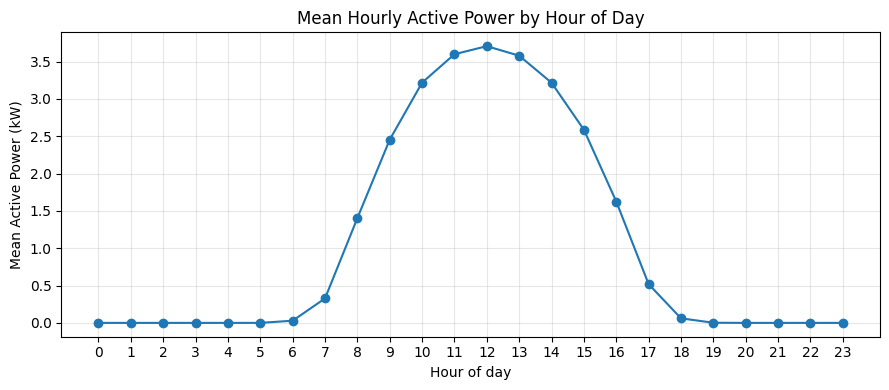

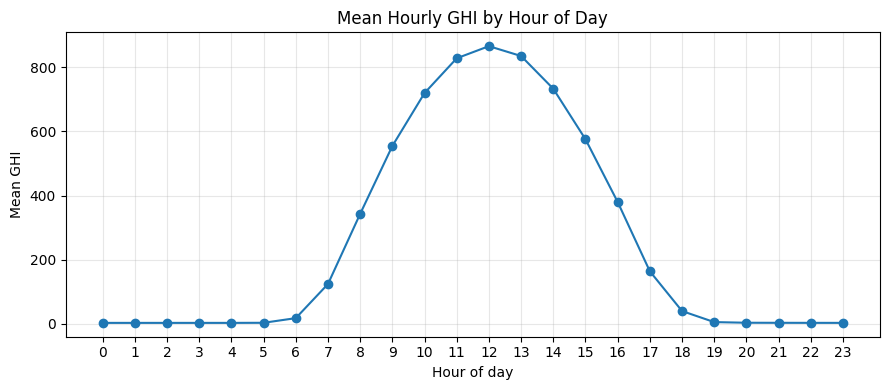

In [14]:
#Average power and irradiance by hour

hourly_profile = (
    df_hourly_audit
    .groupby("hour")
    .agg(
        mean_power_kw=("Active_Power", "mean"),
        median_power_kw=("Active_Power", "median"),
        mean_ghi=("Global_Horizontal_Radiation", "mean"),
        active_power_zero_pct=("Active_Power", lambda x: round(x.eq(0).mean() * 100, 2)),
        rows=("Active_Power", "size")
    )
    .reset_index()
)

display(hourly_profile)

plt.figure(figsize=(9, 4))
plt.plot(hourly_profile["hour"], hourly_profile["mean_power_kw"], marker="o")
plt.title("Mean Hourly Active Power by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Mean Active Power (kW)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(hourly_profile["hour"], hourly_profile["mean_ghi"], marker="o")
plt.title("Mean Hourly GHI by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Mean GHI")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
#Missingness by hour

missing_by_hour = (
    df_hourly_audit
    .groupby("hour")
    .agg(
        rows=("Active_Power", "size"),
        active_power_missing=("Active_Power", lambda x: x.isna().sum()),
        ghi_missing=("Global_Horizontal_Radiation", lambda x: x.isna().sum()),
        temp_missing=("Weather_Temperature_Celsius", lambda x: x.isna().sum()),
        humidity_missing=("Weather_Relative_Humidity", lambda x: x.isna().sum())
    )
    .reset_index()
)

missing_by_hour["active_power_missing_pct"] = (
    missing_by_hour["active_power_missing"] / missing_by_hour["rows"] * 100
).round(2)

display(missing_by_hour)

,hour,rows,active_power_missing,ghi_missing,temp_missing,humidity_missing,active_power_missing_pct
0,0,5371,183,185,194,225,3.41
1,1,5371,181,183,192,233,3.37
2,2,5371,180,182,192,240,3.35
3,3,5371,183,185,195,255,3.41
4,4,5371,180,182,192,273,3.35
5,5,5371,180,182,192,297,3.35
6,6,5371,180,182,193,312,3.35
7,7,5371,184,183,194,312,3.43
8,8,5371,188,183,194,260,3.50
9,9,5371,189,182,193,215,3.52


### Stage 3C — Create daylight hourly modeling dataset

This stage creates the main daylight-only hourly dataset using `Global_Horizontal_Radiation > 50`.

The all-hours hourly dataset is preserved separately.
No missing-value imputation or lag feature creation is done yet.

In [16]:
#Create daylight dataset using GHI > 50

DAYLIGHT_GHI_THRESHOLD = 50

df_hourly_daylight = df_hourly_all[
    df_hourly_all["Global_Horizontal_Radiation"] > DAYLIGHT_GHI_THRESHOLD
].copy()

df_hourly_daylight = df_hourly_daylight.sort_values("timestamp").reset_index(drop=True)

print("df_hourly_daylight created.")
print("Daylight rule: Global_Horizontal_Radiation >", DAYLIGHT_GHI_THRESHOLD)
print("Shape:", df_hourly_daylight.shape)
print("Timestamp range:", df_hourly_daylight["timestamp"].min(), "to", df_hourly_daylight["timestamp"].max())

df_hourly_daylight created.
Daylight rule: Global_Horizontal_Radiation > 50
Shape: (56067, 14)
Timestamp range: 2009-01-16 07:00:00 to 2023-09-30 17:00:00


In [17]:
#Compare all-hours vs daylight dataset

def hourly_dataset_summary(dataframe, name):
    return {
        "dataset": name,
        "rows": len(dataframe),
        "row_pct_of_all_hourly": round(len(dataframe) / len(df_hourly_all) * 100, 2),
        "start": dataframe["timestamp"].min(),
        "end": dataframe["timestamp"].max(),
        "active_power_missing": int(dataframe["Active_Power"].isna().sum()),
        "active_power_missing_pct": round(dataframe["Active_Power"].isna().mean() * 100, 3),
        "active_power_zero": int(dataframe["Active_Power"].eq(0).sum()),
        "active_power_zero_pct": round(dataframe["Active_Power"].eq(0).mean() * 100, 3),
        "mean_power_kw": round(dataframe["Active_Power"].mean(), 3),
        "mean_ghi": round(dataframe["Global_Horizontal_Radiation"].mean(), 2)
    }


hourly_comparison = pd.DataFrame([
    hourly_dataset_summary(df_hourly_all, "all_hours"),
    hourly_dataset_summary(df_hourly_daylight, "daylight_ghi_gt_50")
])

display(hourly_comparison)

,dataset,rows,row_pct_of_all_hourly,start,end,active_power_missing,active_power_missing_pct,active_power_zero,active_power_zero_pct,mean_power_kw,mean_ghi
0,all_hours,128904,100.0,2009-01-16 00:00:00,2023-09-30 23:00:00,4421,3.430,58920,45.708,1.096,258.88
1,daylight_ghi_gt_50,56067,43.5,2009-01-16 07:00:00,2023-09-30 17:00:00,74,0.132,1,0.002,2.417,568.19


In [18]:
#Missing summary for daylight dataset

value_cols = [
    "Active_Power",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Weather_Daily_Rainfall"
]

value_cols = [c for c in value_cols if c in df_hourly_daylight.columns]

daylight_missing_summary = pd.DataFrame({
    "missing_count": df_hourly_daylight[value_cols].isna().sum(),
    "missing_pct": (df_hourly_daylight[value_cols].isna().mean() * 100).round(3)
}).sort_values("missing_count", ascending=False)

display(daylight_missing_summary)

,missing_count,missing_pct
Weather_Relative_Humidity,203,0.362
Active_Power,74,0.132
Weather_Temperature_Celsius,5,0.009
Global_Horizontal_Radiation,0,0.000
Diffuse_Horizontal_Radiation,0,0.000
Weather_Daily_Rainfall,0,0.000


,hour,rows,mean_power_kw,mean_ghi,active_power_missing
0,6,595,0.126483,72.158804,0
1,7,3674,0.434043,163.547895,3
2,8,5070,1.429485,350.357743,7
3,9,5134,2.470277,560.470986,9
4,10,5147,3.228139,725.424040,9
5,11,5138,3.608803,834.560084,8
6,12,5143,3.713537,871.816351,8
7,13,5148,3.586602,840.698832,2
8,14,5154,3.224854,737.856054,5
9,15,5137,2.602268,581.151752,6


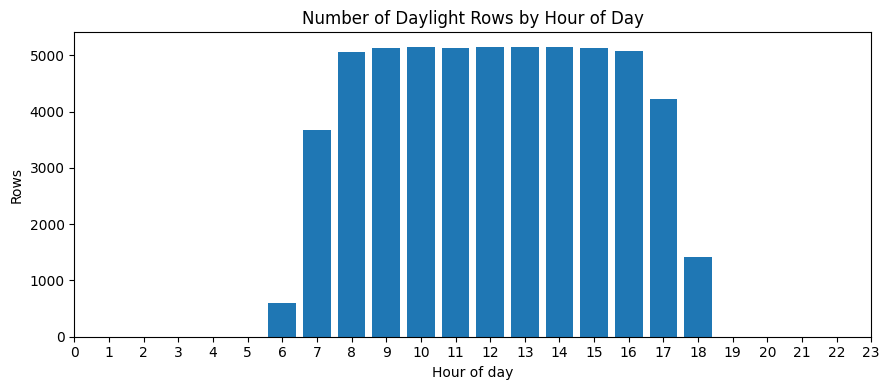

In [19]:
#Check daylight rows by hour

daylight_by_hour = (
    df_hourly_daylight
    .assign(hour=df_hourly_daylight["timestamp"].dt.hour)
    .groupby("hour")
    .agg(
        rows=("Active_Power", "size"),
        mean_power_kw=("Active_Power", "mean"),
        mean_ghi=("Global_Horizontal_Radiation", "mean"),
        active_power_missing=("Active_Power", lambda x: x.isna().sum())
    )
    .reset_index()
)

display(daylight_by_hour)

plt.figure(figsize=(9, 4))
plt.bar(daylight_by_hour["hour"], daylight_by_hour["rows"])
plt.title("Number of Daylight Rows by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Rows")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [20]:
#Save daylight hourly dataset

hourly_daylight_pkl_path = DATA_PROCESSED / "df_hourly_daylight_ghi_gt_50.pkl"
hourly_daylight_csv_path = DATA_PROCESSED / "df_hourly_daylight_ghi_gt_50.csv.gz"

df_hourly_daylight.to_pickle(hourly_daylight_pkl_path)
df_hourly_daylight.to_csv(hourly_daylight_csv_path, index=False, compression="gzip")

print("Saved df_hourly_daylight.")
print("Pickle:", hourly_daylight_pkl_path)
print("CSV:", hourly_daylight_csv_path)
print("Shape:", df_hourly_daylight.shape)

Saved df_hourly_daylight.
Pickle: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_hourly_daylight_ghi_gt_50.pkl
CSV: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_hourly_daylight_ghi_gt_50.csv.gz
Shape: (56067, 14)


### Stage 3D — Remove rows with missing target values

This stage removes daylight hourly rows where the target variable `Active_Power` is missing.

Target values are not imputed because they represent the ground truth that the model is supposed to learn.
Input feature missing values will be handled separately in the next stage.

In [21]:
#Inspect rows with missing target

target_missing_mask = df_hourly_daylight["Active_Power"].isna()

print("Rows with missing Active_Power:", int(target_missing_mask.sum()))
print("Percentage:", round(target_missing_mask.mean() * 100, 3), "%")

inspect_cols = [
    "timestamp",
    "Active_Power",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Weather_Daily_Rainfall",
    "source_5min_rows_present",
    "Active_Power_valid_count",
    "Global_Horizontal_Radiation_valid_count"
]

inspect_cols = [c for c in inspect_cols if c in df_hourly_daylight.columns]

display(df_hourly_daylight.loc[target_missing_mask, inspect_cols].head(30))

Rows with missing Active_Power: 74
Percentage: 0.132 %


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall,source_5min_rows_present,Active_Power_valid_count,Global_Horizontal_Radiation_valid_count
3616,2009-12-20 08:00:00,NaN,549.736987,99.333674,27.598950,16.978699,0.0,12,3,12
3617,2009-12-20 09:00:00,NaN,734.919535,159.149026,29.445053,14.699062,0.0,12,0,12
3618,2009-12-20 10:00:00,NaN,831.849859,343.082600,30.831176,14.564544,0.0,12,9,12
4234,2010-02-09 11:00:00,NaN,1009.925766,110.429888,34.236538,27.808170,0.0,12,5,12
4235,2010-02-09 12:00:00,NaN,1014.903539,103.852528,35.117699,25.269369,0.0,12,5,12
4562,2010-03-10 12:00:00,NaN,1048.151901,83.763412,25.378408,32.228482,0.0,12,4,12
4563,2010-03-10 13:00:00,NaN,1040.960607,88.278168,26.305943,30.604079,0.0,12,8,12
6070,2010-08-13 08:00:00,NaN,275.996161,33.806005,10.926143,51.942760,0.0,12,8,12
6071,2010-08-13 09:00:00,NaN,506.112005,48.564987,14.208412,40.264861,0.0,12,0,12
6072,2010-08-13 10:00:00,NaN,680.695770,57.863518,16.495244,32.546227,0.0,12,9,12


In [22]:
#Drop rows with missing target

df_hourly_daylight_target_clean = df_hourly_daylight.loc[
    df_hourly_daylight["Active_Power"].notna()
].copy()

df_hourly_daylight_target_clean = (
    df_hourly_daylight_target_clean
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print("Before dropping missing target:", df_hourly_daylight.shape)
print("After dropping missing target:", df_hourly_daylight_target_clean.shape)
print("Rows removed:", len(df_hourly_daylight) - len(df_hourly_daylight_target_clean))

display(df_hourly_daylight_target_clean.head())
display(df_hourly_daylight_target_clean.tail())

Before dropping missing target: (56067, 14)
After dropping missing target: (55993, 14)
Rows removed: 74


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall,Active_Power_valid_count,Global_Horizontal_Radiation_valid_count,Diffuse_Horizontal_Radiation_valid_count,Weather_Temperature_Celsius_valid_count,Weather_Relative_Humidity_valid_count,Weather_Daily_Rainfall_valid_count,source_5min_rows_present
0,2009-01-16 07:00:00,0.574844,248.154828,53.916469,27.617435,24.730025,0.0,12,12,12,12,12,12,12
1,2009-01-16 08:00:00,1.953644,499.633525,74.188646,29.505454,19.339665,0.0,12,12,12,12,12,12,12
2,2009-01-16 09:00:00,3.049669,723.786123,93.041066,30.461270,17.189833,0.0,12,12,12,12,12,12,12
3,2009-01-16 10:00:00,3.777403,908.317169,114.716789,32.089284,16.280571,0.0,12,12,12,12,12,12,12
4,2009-01-16 11:00:00,4.201639,1040.136866,136.682472,33.535577,15.546692,0.0,12,12,12,12,12,12,12


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall,Active_Power_valid_count,Global_Horizontal_Radiation_valid_count,Diffuse_Horizontal_Radiation_valid_count,Weather_Temperature_Celsius_valid_count,Weather_Relative_Humidity_valid_count,Weather_Daily_Rainfall_valid_count,source_5min_rows_present
55988,2023-09-30 13:00:00,2.060100,575.120794,274.384832,34.415135,9.767379,0.0,12,12,12,12,12,12,12
55989,2023-09-30 14:00:00,2.239317,561.257732,260.735093,34.809876,9.494566,0.0,12,12,12,12,12,12,12
55990,2023-09-30 15:00:00,2.603722,637.263162,170.684111,35.150859,9.187579,0.0,12,12,12,12,12,12,12
55991,2023-09-30 16:00:00,1.055781,273.522446,120.577508,34.555827,9.302099,0.0,12,12,12,12,12,12,12
55992,2023-09-30 17:00:00,0.457261,160.388524,89.998359,34.171843,9.409500,0.0,12,12,12,12,12,12,12


In [23]:
#Missing summary after target cleaning

missing_after_target_clean = pd.DataFrame({
    "missing_count": df_hourly_daylight_target_clean.isna().sum(),
    "missing_pct": (df_hourly_daylight_target_clean.isna().mean() * 100).round(3)
}).sort_values("missing_count", ascending=False)

display(missing_after_target_clean)

,missing_count,missing_pct
Weather_Relative_Humidity,203,0.363
Weather_Temperature_Celsius,5,0.009
Active_Power,0,0.000
timestamp,0,0.000
Diffuse_Horizontal_Radiation,0,0.000
Global_Horizontal_Radiation,0,0.000
Weather_Daily_Rainfall,0,0.000
Active_Power_valid_count,0,0.000
Global_Horizontal_Radiation_valid_count,0,0.000
Diffuse_Horizontal_Radiation_valid_count,0,0.000


In [24]:
#Save target-clean daylight dataset

target_clean_pkl_path = DATA_PROCESSED / "df_hourly_daylight_target_clean.pkl"
target_clean_csv_path = DATA_PROCESSED / "df_hourly_daylight_target_clean.csv.gz"

df_hourly_daylight_target_clean.to_pickle(target_clean_pkl_path)
df_hourly_daylight_target_clean.to_csv(target_clean_csv_path, index=False, compression="gzip")

print("Saved df_hourly_daylight_target_clean.")
print("Pickle:", target_clean_pkl_path)
print("CSV:", target_clean_csv_path)
print("Shape:", df_hourly_daylight_target_clean.shape)

Saved df_hourly_daylight_target_clean.
Pickle: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_hourly_daylight_target_clean.pkl
CSV: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_hourly_daylight_target_clean.csv.gz
Shape: (55993, 14)


### Stage 3E — Remove remaining missing input feature rows

The target variable `Active_Power` has already been cleaned.

This stage removes the very small number of remaining rows where key input weather features are missing.
Because the missing feature rate is below 0.5%, dropping these rows is simpler and more defensible than imputing artificial meteorological values.

This stage also creates a clean hourly daylight model-base dataset using only the target and selected input columns.

In [25]:
#Define final base columns

model_base_cols = [
    "timestamp",
    "Active_Power",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Weather_Daily_Rainfall"
]

missing_cols = [c for c in model_base_cols if c not in df_hourly_daylight_target_clean.columns]

if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

df_model_base_before_missing_drop = df_hourly_daylight_target_clean[model_base_cols].copy()

print("Model base before missing feature drop:")
print(df_model_base_before_missing_drop.shape)
display(df_model_base_before_missing_drop.head())

Model base before missing feature drop:
(55993, 7)


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall
0,2009-01-16 07:00:00,0.574844,248.154828,53.916469,27.617435,24.730025,0.0
1,2009-01-16 08:00:00,1.953644,499.633525,74.188646,29.505454,19.339665,0.0
2,2009-01-16 09:00:00,3.049669,723.786123,93.041066,30.461270,17.189833,0.0
3,2009-01-16 10:00:00,3.777403,908.317169,114.716789,32.089284,16.280571,0.0
4,2009-01-16 11:00:00,4.201639,1040.136866,136.682472,33.535577,15.546692,0.0


In [26]:
#Inspect rows with missing input features

input_feature_cols = [
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Weather_Daily_Rainfall"
]

missing_input_mask = df_model_base_before_missing_drop[input_feature_cols].isna().any(axis=1)

print("Rows with at least one missing input feature:", int(missing_input_mask.sum()))
print("Percentage:", round(missing_input_mask.mean() * 100, 3), "%")

display(
    df_model_base_before_missing_drop
    .loc[missing_input_mask]
    .head(30)
)

Rows with at least one missing input feature: 208
Percentage: 0.371 %


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall
20466,2014-04-08 13:00:00,1.326261,246.075340,238.479075,18.334084,NaN,21.966666
20479,2014-04-10 07:00:00,0.295978,85.911189,17.289670,16.986763,NaN,0.200000
20931,2014-05-23 08:00:00,1.067433,265.352454,33.546604,14.994365,NaN,0.400000
21429,2014-07-14 08:00:00,0.340822,83.211521,78.610429,6.925149,NaN,4.050000
21438,2014-07-15 08:00:00,0.847033,169.504871,38.483106,10.524018,NaN,1.450000
21448,2014-07-16 08:00:00,0.915478,188.573630,33.609258,8.470505,NaN,1.000000
21458,2014-07-17 08:00:00,0.934444,196.603491,34.799028,7.265726,NaN,0.000000
23460,2015-01-12 07:00:00,0.371200,78.420768,76.665665,20.128436,NaN,0.666667
24578,2015-04-19 07:00:00,0.244556,81.965930,51.404548,12.251520,NaN,0.200000
25147,2015-06-14 08:00:00,0.542261,112.335950,104.317442,12.666243,NaN,0.000000


In [27]:
#Drop rows with missing input features

df_hourly_daylight_model_base = df_model_base_before_missing_drop.loc[
    ~missing_input_mask
].copy()

df_hourly_daylight_model_base = (
    df_hourly_daylight_model_base
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print("Before dropping missing input rows:", df_model_base_before_missing_drop.shape)
print("After dropping missing input rows:", df_hourly_daylight_model_base.shape)
print("Rows removed:", len(df_model_base_before_missing_drop) - len(df_hourly_daylight_model_base))

display(df_hourly_daylight_model_base.head())
display(df_hourly_daylight_model_base.tail())

Before dropping missing input rows: (55993, 7)
After dropping missing input rows: (55785, 7)
Rows removed: 208


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall
0,2009-01-16 07:00:00,0.574844,248.154828,53.916469,27.617435,24.730025,0.0
1,2009-01-16 08:00:00,1.953644,499.633525,74.188646,29.505454,19.339665,0.0
2,2009-01-16 09:00:00,3.049669,723.786123,93.041066,30.461270,17.189833,0.0
3,2009-01-16 10:00:00,3.777403,908.317169,114.716789,32.089284,16.280571,0.0
4,2009-01-16 11:00:00,4.201639,1040.136866,136.682472,33.535577,15.546692,0.0


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall
55780,2023-09-30 13:00:00,2.060100,575.120794,274.384832,34.415135,9.767379,0.0
55781,2023-09-30 14:00:00,2.239317,561.257732,260.735093,34.809876,9.494566,0.0
55782,2023-09-30 15:00:00,2.603722,637.263162,170.684111,35.150859,9.187579,0.0
55783,2023-09-30 16:00:00,1.055781,273.522446,120.577508,34.555827,9.302099,0.0
55784,2023-09-30 17:00:00,0.457261,160.388524,89.998359,34.171843,9.409500,0.0


In [28]:
#Verify final missing values

model_base_missing_summary = pd.DataFrame({
    "missing_count": df_hourly_daylight_model_base.isna().sum(),
    "missing_pct": (df_hourly_daylight_model_base.isna().mean() * 100).round(3)
}).sort_values("missing_count", ascending=False)

display(model_base_missing_summary)

print("Final model-base shape:", df_hourly_daylight_model_base.shape)
print("Timestamp range:", df_hourly_daylight_model_base["timestamp"].min(), "to", df_hourly_daylight_model_base["timestamp"].max())

,missing_count,missing_pct
timestamp,0,0.0
Active_Power,0,0.0
Global_Horizontal_Radiation,0,0.0
Diffuse_Horizontal_Radiation,0,0.0
Weather_Temperature_Celsius,0,0.0
Weather_Relative_Humidity,0,0.0
Weather_Daily_Rainfall,0,0.0


Final model-base shape: (55785, 7)
Timestamp range: 2009-01-16 07:00:00 to 2023-09-30 17:00:00


In [29]:
#Save clean hourly daylight model-base dataset

model_base_pkl_path = DATA_PROCESSED / "df_hourly_daylight_model_base.pkl"
model_base_csv_path = DATA_PROCESSED / "df_hourly_daylight_model_base.csv.gz"

df_hourly_daylight_model_base.to_pickle(model_base_pkl_path)
df_hourly_daylight_model_base.to_csv(model_base_csv_path, index=False, compression="gzip")

print("Saved df_hourly_daylight_model_base.")
print("Pickle:", model_base_pkl_path)
print("CSV:", model_base_csv_path)
print("Shape:", df_hourly_daylight_model_base.shape)

Saved df_hourly_daylight_model_base.
Pickle: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_hourly_daylight_model_base.pkl
CSV: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_hourly_daylight_model_base.csv.gz
Shape: (55785, 7)


### Stage 4A — Time continuity audit before lag feature engineering

This stage checks the timestamp gaps in the clean daylight hourly dataset.

Because night-time rows were removed, simple row-based shifting can create incorrect lag features across overnight gaps. This audit helps decide how lag features should be created safely.

In [30]:
#Check timestamp gaps between consecutive daylight rows

#This will probably show many 1-hour gaps, but also overnight gaps like 13, 14, or 15 hours. That is expected.

df_time_audit = df_hourly_daylight_model_base.copy()

df_time_audit["time_delta"] = df_time_audit["timestamp"].diff()

delta_counts = (
    df_time_audit["time_delta"]
    .value_counts()
    .head(20)
    .reset_index()
)

delta_counts.columns = ["time_gap", "count"]

display(delta_counts)

,time_gap,count
0,0 days 01:00:00,50486
1,0 days 14:00:00,1836
2,0 days 13:00:00,1086
3,0 days 15:00:00,1061
4,0 days 16:00:00,608
5,0 days 12:00:00,434
6,0 days 02:00:00,102
7,0 days 17:00:00,76
8,0 days 18:00:00,28
9,0 days 03:00:00,14


In [31]:
#Identify rows where previous row is not previous hour

#This will show why we must avoid careless .shift(1) on daylight-only data.

non_1h_gap_mask = df_time_audit["time_delta"].notna() & (
    df_time_audit["time_delta"] != pd.Timedelta(hours=1)
)

non_1h_gaps = df_time_audit.loc[
    non_1h_gap_mask,
    ["timestamp", "time_delta", "Active_Power", "Global_Horizontal_Radiation"]
].copy()

print("Rows where previous daylight row is not exactly 1 hour before:", len(non_1h_gaps))
print("Percentage:", round(len(non_1h_gaps) / len(df_time_audit) * 100, 2), "%")

display(non_1h_gaps.head(20))
display(non_1h_gaps.tail(20))

Rows where previous daylight row is not exactly 1 hour before: 5298
Percentage: 9.5 %


,timestamp,time_delta,Active_Power,Global_Horizontal_Radiation
12,2009-01-17 07:00:00,0 days 13:00:00,0.649817,229.742687
24,2009-01-18 08:00:00,0 days 14:00:00,0.276611,56.319402
34,2009-01-19 07:00:00,0 days 14:00:00,0.386261,96.922548
46,2009-01-20 07:00:00,0 days 13:00:00,0.614667,151.479723
58,2009-01-21 07:00:00,0 days 13:00:00,0.705794,223.898628
70,2009-01-22 07:00:00,0 days 13:00:00,0.619986,186.046918
82,2009-01-23 07:00:00,0 days 13:00:00,0.574311,197.947572
94,2009-01-24 06:00:00,0 days 12:00:00,0.227794,62.009476
107,2009-01-25 07:00:00,0 days 13:00:00,0.498250,206.286276
119,2009-01-26 07:00:00,0 days 13:00:00,0.508006,217.436557


,timestamp,time_delta,Active_Power,Global_Horizontal_Radiation
55565,2023-09-11 07:00:00,0 days 14:00:00,0.421703,133.301617
55576,2023-09-12 07:00:00,0 days 14:00:00,0.486939,155.740169
55587,2023-09-13 07:00:00,0 days 14:00:00,0.485194,157.441813
55598,2023-09-14 07:00:00,0 days 14:00:00,0.469217,149.720613
55609,2023-09-15 07:00:00,0 days 14:00:00,0.494989,154.347227
55620,2023-09-16 07:00:00,0 days 14:00:00,0.499633,147.370468
55631,2023-09-17 07:00:00,0 days 14:00:00,0.503244,153.435027
55642,2023-09-18 07:00:00,0 days 14:00:00,0.508953,155.887039
55653,2023-09-19 07:00:00,0 days 14:00:00,0.462892,133.160278
55664,2023-09-20 07:00:00,0 days 14:00:00,0.500197,156.193199


,hour,rows
0,6,590
1,7,3623
2,8,5004
3,9,5096
4,10,5119
5,11,5119
6,12,5123
7,13,5135
8,14,5140
9,15,5127


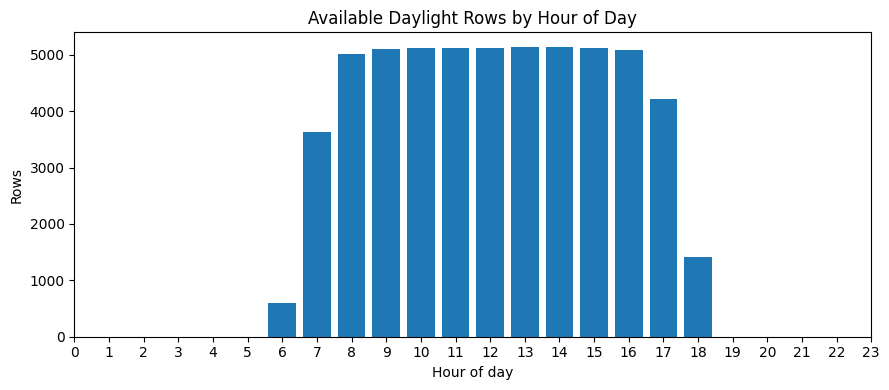

In [32]:
#Visualize daylight rows by hour

#This gives us a simple check of which hours survived the GHI > 50 daylight filter.

daylight_hour_counts = (
    df_hourly_daylight_model_base
    .assign(hour=df_hourly_daylight_model_base["timestamp"].dt.hour)
    .groupby("hour")
    .size()
    .reset_index(name="rows")
)

display(daylight_hour_counts)

plt.figure(figsize=(9, 4))
plt.bar(daylight_hour_counts["hour"], daylight_hour_counts["rows"])
plt.title("Available Daylight Rows by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Rows")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

### Stage 4B — Prepare timestamp-safe lag source and target table

This stage prepares the feature-engineering base.

Target rows come from the clean daylight dataset.
Lag values will be retrieved from the full hourly all-hours dataset using exact timestamp offsets.

No lag features are created yet. This stage only audits whether timestamp-based lags are available.

In [33]:
#Create lag source and target table

source_cols = [
    "timestamp",
    "Active_Power",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Weather_Daily_Rainfall"
]

df_lag_source = df_hourly_all[source_cols].copy()
df_lag_source = df_lag_source.sort_values("timestamp").reset_index(drop=True)

df_target_daylight = df_hourly_daylight_model_base[
    ["timestamp", "Active_Power"]
].copy()

df_target_daylight = df_target_daylight.rename(
    columns={"Active_Power": "y_active_power"}
)

df_target_daylight = df_target_daylight.sort_values("timestamp").reset_index(drop=True)

print("Lag source shape:", df_lag_source.shape)
print("Target daylight shape:", df_target_daylight.shape)

display(df_lag_source.head())
display(df_target_daylight.head())

Lag source shape: (128904, 7)
Target daylight shape: (55785, 2)


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall
0,2009-01-16 00:00:00,0.0,3.935616,1.244092,30.701613,27.677885,0.0
1,2009-01-16 01:00:00,0.0,3.677840,1.053063,29.542114,29.981298,0.0
2,2009-01-16 02:00:00,0.0,4.119222,1.257988,28.784745,31.614559,0.0
3,2009-01-16 03:00:00,0.0,3.417286,0.833788,28.370600,30.678571,0.0
4,2009-01-16 04:00:00,0.0,4.107748,1.257499,27.128516,31.801350,0.0


,timestamp,y_active_power
0,2009-01-16 07:00:00,0.574844
1,2009-01-16 08:00:00,1.953644
2,2009-01-16 09:00:00,3.049669
3,2009-01-16 10:00:00,3.777403
4,2009-01-16 11:00:00,4.201639


In [34]:
#Audit candidate lag availability

candidate_lags_hours = [1, 2, 3, 6, 24, 48]

lag_feature_cols = [
    "Active_Power",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Weather_Daily_Rainfall"
]

lag_availability_rows = []

for lag_h in candidate_lags_hours:
    lag_times = df_target_daylight["timestamp"] - pd.Timedelta(hours=lag_h)

    temp = pd.DataFrame({
        "target_timestamp": df_target_daylight["timestamp"],
        "lag_timestamp": lag_times
    })

    lookup = df_lag_source.copy()
    lookup = lookup.rename(columns={"timestamp": "lag_timestamp"})

    merged = temp.merge(lookup, on="lag_timestamp", how="left")

    timestamp_available = merged["Active_Power"].notna() | merged[lag_feature_cols].notna().any(axis=1)
    all_lag_features_available = merged[lag_feature_cols].notna().all(axis=1)

    lag_availability_rows.append({
        "lag_hours": lag_h,
        "target_rows": len(df_target_daylight),
        "rows_with_lag_timestamp_available": int(timestamp_available.sum()),
        "timestamp_available_pct": round(timestamp_available.mean() * 100, 3),
        "rows_with_all_lag_features_available": int(all_lag_features_available.sum()),
        "all_lag_features_available_pct": round(all_lag_features_available.mean() * 100, 3)
    })

lag_availability = pd.DataFrame(lag_availability_rows)

display(lag_availability)

,lag_hours,target_rows,rows_with_lag_timestamp_available,timestamp_available_pct,rows_with_all_lag_features_available,all_lag_features_available_pct
0,1,55785,55749,99.935,55520,99.525
1,2,55785,55738,99.916,55363,99.244
2,3,55785,55730,99.901,55230,99.005
3,6,55785,55716,99.876,55004,98.600
4,24,55785,55600,99.668,55241,99.025
5,48,55785,55500,99.489,55078,98.733


In [35]:
#Inspect unavailable 1-hour lag examples

lag_h = 1

lag_times = df_target_daylight["timestamp"] - pd.Timedelta(hours=lag_h)

temp = pd.DataFrame({
    "target_timestamp": df_target_daylight["timestamp"],
    "lag_timestamp": lag_times
})

lookup = df_lag_source.rename(columns={"timestamp": "lag_timestamp"})

merged_lag1 = temp.merge(lookup, on="lag_timestamp", how="left")

lag1_missing_mask = merged_lag1[lag_feature_cols].isna().any(axis=1)

print("Rows where 1-hour lag has at least one missing lag feature:", int(lag1_missing_mask.sum()))
print("Percentage:", round(lag1_missing_mask.mean() * 100, 3), "%")

display(merged_lag1.loc[lag1_missing_mask].head(30))

Rows where 1-hour lag has at least one missing lag feature: 265
Percentage: 0.475 %


,target_timestamp,lag_timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall
3616,2009-12-20 11:00:00,2009-12-20 10:00:00,NaN,831.849859,343.082600,30.831176,14.564544,0.0
4231,2010-02-09 13:00:00,2010-02-09 12:00:00,NaN,1014.903539,103.852528,35.117699,25.269369,0.0
4557,2010-03-10 14:00:00,2010-03-10 13:00:00,NaN,1040.960607,88.278168,26.305943,30.604079,0.0
6063,2010-08-13 11:00:00,2010-08-13 10:00:00,NaN,680.695770,57.863518,16.495244,32.546227,0.0
6187,2010-08-26 14:00:00,2010-08-26 13:00:00,NaN,872.416168,67.516624,16.278975,40.967924,0.2
6859,2010-10-29 11:00:00,2010-10-29 10:00:00,NaN,419.259853,383.858074,29.097960,30.292010,0.0
6989,2010-11-09 10:00:00,2010-11-09 09:00:00,NaN,788.863541,69.017108,26.255079,41.346339,0.0
7196,2010-11-26 11:00:00,2010-11-26 10:00:00,NaN,650.113810,355.055186,27.294575,55.186609,1.2
7208,2010-11-27 12:00:00,2010-11-27 11:00:00,3.682139,NaN,358.020915,26.632035,51.840309,0.0
7651,2011-01-01 16:00:00,2011-01-01 15:00:00,NaN,233.204702,227.147270,26.576964,79.992742,7.2


### Stage 4C — Create timestamp-safe lag feature dataset

This stage creates the first model-ready supervised learning table.

Each row represents a daylight target hour `t`.
The target is `Active_Power` at time `t`.
Input features are created from exact timestamp-based lag values, such as `t-1h`, `t-2h`, `t-3h`, and `t-24h`.

No row-based `.shift()` is used on the daylight-only dataset.

In [36]:
#Create base supervised table

df_features = df_hourly_daylight_model_base[["timestamp", "Active_Power"]].copy()

df_features = df_features.rename(columns={
    "Active_Power": "y_active_power"
})

df_features = df_features.sort_values("timestamp").reset_index(drop=True)

print("Base supervised table created.")
print(df_features.shape)
display(df_features.head())

Base supervised table created.
(55785, 2)


,timestamp,y_active_power
0,2009-01-16 07:00:00,0.574844
1,2009-01-16 08:00:00,1.953644
2,2009-01-16 09:00:00,3.049669
3,2009-01-16 10:00:00,3.777403
4,2009-01-16 11:00:00,4.201639


In [37]:
#Add time/calendar features

df_features["hour"] = df_features["timestamp"].dt.hour
df_features["day_of_year"] = df_features["timestamp"].dt.dayofyear
df_features["month"] = df_features["timestamp"].dt.month

# Cyclical encodings help ML models understand repeating time patterns.
df_features["hour_sin"] = np.sin(2 * np.pi * df_features["hour"] / 24)
df_features["hour_cos"] = np.cos(2 * np.pi * df_features["hour"] / 24)

df_features["dayofyear_sin"] = np.sin(2 * np.pi * df_features["day_of_year"] / 365.25)
df_features["dayofyear_cos"] = np.cos(2 * np.pi * df_features["day_of_year"] / 365.25)

print("Time features added.")
display(df_features.head())

Time features added.


,timestamp,y_active_power,hour,day_of_year,month,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos
0,2009-01-16 07:00:00,0.574844,7,16,1,0.965926,-0.258819,0.271777,0.96236
1,2009-01-16 08:00:00,1.953644,8,16,1,0.866025,-0.500000,0.271777,0.96236
2,2009-01-16 09:00:00,3.049669,9,16,1,0.707107,-0.707107,0.271777,0.96236
3,2009-01-16 10:00:00,3.777403,10,16,1,0.500000,-0.866025,0.271777,0.96236
4,2009-01-16 11:00:00,4.201639,11,16,1,0.258819,-0.965926,0.271777,0.96236


In [38]:
#Prepare lag source table

lag_source_cols = [
    "timestamp",
    "Active_Power",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Weather_Daily_Rainfall"
]

df_lag_source = df_hourly_all[lag_source_cols].copy()
df_lag_source["timestamp"] = pd.to_datetime(df_lag_source["timestamp"])
df_lag_source = df_lag_source.sort_values("timestamp").reset_index(drop=True)

print("Lag source prepared.")
print(df_lag_source.shape)
display(df_lag_source.head())

Lag source prepared.
(128904, 7)


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall
0,2009-01-16 00:00:00,0.0,3.935616,1.244092,30.701613,27.677885,0.0
1,2009-01-16 01:00:00,0.0,3.677840,1.053063,29.542114,29.981298,0.0
2,2009-01-16 02:00:00,0.0,4.119222,1.257988,28.784745,31.614559,0.0
3,2009-01-16 03:00:00,0.0,3.417286,0.833788,28.370600,30.678571,0.0
4,2009-01-16 04:00:00,0.0,4.107748,1.257499,27.128516,31.801350,0.0


In [39]:
#Add timestamp-based lag features

def add_timestamp_lag_features(base_df, source_df, lag_hours, columns_to_lag):
    """
    Adds lag features using exact timestamp matching.

    For each target timestamp t, this fetches source values at:
    t - lag_hours
    """
    result = base_df.copy()

    lag_lookup = source_df[["timestamp"] + columns_to_lag].copy()
    lag_lookup = lag_lookup.rename(columns={"timestamp": "lag_timestamp"})

    rename_map = {
        col: f"{col}_lag_{lag_hours}h"
        for col in columns_to_lag
    }

    lag_lookup = lag_lookup.rename(columns=rename_map)

    temp = pd.DataFrame({
        "timestamp": result["timestamp"],
        "lag_timestamp": result["timestamp"] - pd.Timedelta(hours=lag_hours)
    })

    temp = temp.merge(lag_lookup, on="lag_timestamp", how="left")
    temp = temp.drop(columns=["lag_timestamp"])

    result = result.merge(temp, on="timestamp", how="left")

    return result

In [40]:
# Power lags: past PV output
power_lag_cols = ["Active_Power"]

for lag_h in [1, 2, 3, 24]:
    df_features = add_timestamp_lag_features(
        base_df=df_features,
        source_df=df_lag_source,
        lag_hours=lag_h,
        columns_to_lag=power_lag_cols
    )

# Weather lags: use recent observed weather only
weather_lag_cols = [
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Weather_Daily_Rainfall"
]

for lag_h in [1]:
    df_features = add_timestamp_lag_features(
        base_df=df_features,
        source_df=df_lag_source,
        lag_hours=lag_h,
        columns_to_lag=weather_lag_cols
    )

print("Lag features added.")
print(df_features.shape)
display(df_features.head())

Lag features added.
(55785, 18)


,timestamp,y_active_power,hour,day_of_year,month,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos,Active_Power_lag_1h,Active_Power_lag_2h,Active_Power_lag_3h,Active_Power_lag_24h,Global_Horizontal_Radiation_lag_1h,Diffuse_Horizontal_Radiation_lag_1h,Weather_Temperature_Celsius_lag_1h,Weather_Relative_Humidity_lag_1h,Weather_Daily_Rainfall_lag_1h
0,2009-01-16 07:00:00,0.574844,7,16,1,0.965926,-0.258819,0.271777,0.96236,0.063367,0.000000,0.000000,NaN,29.118333,20.866705,25.621978,30.499445,0.0
1,2009-01-16 08:00:00,1.953644,8,16,1,0.866025,-0.500000,0.271777,0.96236,0.574844,0.063367,0.000000,NaN,248.154828,53.916469,27.617435,24.730025,0.0
2,2009-01-16 09:00:00,3.049669,9,16,1,0.707107,-0.707107,0.271777,0.96236,1.953644,0.574844,0.063367,NaN,499.633525,74.188646,29.505454,19.339665,0.0
3,2009-01-16 10:00:00,3.777403,10,16,1,0.500000,-0.866025,0.271777,0.96236,3.049669,1.953644,0.574844,NaN,723.786123,93.041066,30.461270,17.189833,0.0
4,2009-01-16 11:00:00,4.201639,11,16,1,0.258819,-0.965926,0.271777,0.96236,3.777403,3.049669,1.953644,NaN,908.317169,114.716789,32.089284,16.280571,0.0


In [41]:
#Check missing values after lag creation

feature_missing_summary = pd.DataFrame({
    "missing_count": df_features.isna().sum(),
    "missing_pct": (df_features.isna().mean() * 100).round(3)
}).sort_values("missing_count", ascending=False)

display(feature_missing_summary)

,missing_count,missing_pct
Active_Power_lag_24h,260,0.466
Weather_Relative_Humidity_lag_1h,198,0.355
Active_Power_lag_3h,101,0.181
Active_Power_lag_2h,91,0.163
Active_Power_lag_1h,74,0.133
Global_Horizontal_Radiation_lag_1h,66,0.118
Weather_Temperature_Celsius_lag_1h,42,0.075
Diffuse_Horizontal_Radiation_lag_1h,39,0.070
Weather_Daily_Rainfall_lag_1h,38,0.068
timestamp,0,0.000


### Stage 4D — Create clean model-ready feature table

This stage removes rows where any required lag/time feature is missing.

Because missing lag-feature rows are less than 0.5% of the dataset, dropping these rows is cleaner and more defensible than imputing artificial lag values.

The output is the first model-ready feature dataset: `df_model_features_v1`.

In [42]:
df_features.head()

,timestamp,y_active_power,hour,day_of_year,month,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos,Active_Power_lag_1h,Active_Power_lag_2h,Active_Power_lag_3h,Active_Power_lag_24h,Global_Horizontal_Radiation_lag_1h,Diffuse_Horizontal_Radiation_lag_1h,Weather_Temperature_Celsius_lag_1h,Weather_Relative_Humidity_lag_1h,Weather_Daily_Rainfall_lag_1h
0,2009-01-16 07:00:00,0.574844,7,16,1,0.965926,-0.258819,0.271777,0.96236,0.063367,0.000000,0.000000,NaN,29.118333,20.866705,25.621978,30.499445,0.0
1,2009-01-16 08:00:00,1.953644,8,16,1,0.866025,-0.500000,0.271777,0.96236,0.574844,0.063367,0.000000,NaN,248.154828,53.916469,27.617435,24.730025,0.0
2,2009-01-16 09:00:00,3.049669,9,16,1,0.707107,-0.707107,0.271777,0.96236,1.953644,0.574844,0.063367,NaN,499.633525,74.188646,29.505454,19.339665,0.0
3,2009-01-16 10:00:00,3.777403,10,16,1,0.500000,-0.866025,0.271777,0.96236,3.049669,1.953644,0.574844,NaN,723.786123,93.041066,30.461270,17.189833,0.0
4,2009-01-16 11:00:00,4.201639,11,16,1,0.258819,-0.965926,0.271777,0.96236,3.777403,3.049669,1.953644,NaN,908.317169,114.716789,32.089284,16.280571,0.0


In [43]:
#Define model feature columns and inspect missing rows

# Required columns for the first model-ready feature table

target_col = "y_active_power"

feature_cols = [
    "hour",
    "day_of_year",
    "month",
    "hour_sin",
    "hour_cos",
    "dayofyear_sin",
    "dayofyear_cos",
    "Active_Power_lag_1h",
    "Active_Power_lag_2h",
    "Active_Power_lag_3h",
    "Active_Power_lag_24h",
    "Global_Horizontal_Radiation_lag_1h",
    "Diffuse_Horizontal_Radiation_lag_1h",
    "Weather_Temperature_Celsius_lag_1h",
    "Weather_Relative_Humidity_lag_1h",
    "Weather_Daily_Rainfall_lag_1h"
]

required_cols = ["timestamp", target_col] + feature_cols

missing_required_cols = [c for c in required_cols if c not in df_features.columns]

if missing_required_cols:
    raise ValueError(f"Missing required columns: {missing_required_cols}")

missing_feature_mask = df_features[feature_cols].isna().any(axis=1)

print("Total rows before feature-missing drop:", len(df_features))
print("Rows with at least one missing feature:", int(missing_feature_mask.sum()))
print("Percentage:", round(missing_feature_mask.mean() * 100, 3), "%")

display(
    df_features.loc[missing_feature_mask, required_cols]
    .head(20)
)

Total rows before feature-missing drop: 55785
Rows with at least one missing feature: 634
Percentage: 1.137 %


,timestamp,y_active_power,hour,day_of_year,month,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos,Active_Power_lag_1h,Active_Power_lag_2h,Active_Power_lag_3h,Active_Power_lag_24h,Global_Horizontal_Radiation_lag_1h,Diffuse_Horizontal_Radiation_lag_1h,Weather_Temperature_Celsius_lag_1h,Weather_Relative_Humidity_lag_1h,Weather_Daily_Rainfall_lag_1h
0,2009-01-16 07:00:00,0.574844,7,16,1,9.659258e-01,-2.588190e-01,0.271777,0.962360,0.063367,0.000000,0.000000,NaN,29.118333,20.866705,25.621978,30.499445,0.0
1,2009-01-16 08:00:00,1.953644,8,16,1,8.660254e-01,-5.000000e-01,0.271777,0.962360,0.574844,0.063367,0.000000,NaN,248.154828,53.916469,27.617435,24.730025,0.0
2,2009-01-16 09:00:00,3.049669,9,16,1,7.071068e-01,-7.071068e-01,0.271777,0.962360,1.953644,0.574844,0.063367,NaN,499.633525,74.188646,29.505454,19.339665,0.0
3,2009-01-16 10:00:00,3.777403,10,16,1,5.000000e-01,-8.660254e-01,0.271777,0.962360,3.049669,1.953644,0.574844,NaN,723.786123,93.041066,30.461270,17.189833,0.0
4,2009-01-16 11:00:00,4.201639,11,16,1,2.588190e-01,-9.659258e-01,0.271777,0.962360,3.777403,3.049669,1.953644,NaN,908.317169,114.716789,32.089284,16.280571,0.0
5,2009-01-16 12:00:00,4.220267,12,16,1,1.224647e-16,-1.000000e+00,0.271777,0.962360,4.201639,3.777403,3.049669,NaN,1040.136866,136.682472,33.535577,15.546692,0.0
6,2009-01-16 13:00:00,4.300667,13,16,1,-2.588190e-01,-9.659258e-01,0.271777,0.962360,4.220267,4.201639,3.777403,NaN,1084.301931,138.974331,34.744634,15.125745,0.0
7,2009-01-16 14:00:00,3.966795,14,16,1,-5.000000e-01,-8.660254e-01,0.271777,0.962360,4.300667,4.220267,4.201639,NaN,1069.344950,155.484057,35.552464,15.508102,0.0
8,2009-01-16 15:00:00,3.335822,15,16,1,-7.071068e-01,-7.071068e-01,0.271777,0.962360,3.966795,4.300667,4.220267,NaN,981.271474,167.271782,36.601007,15.086305,0.0
9,2009-01-16 16:00:00,2.443750,16,16,1,-8.660254e-01,-5.000000e-01,0.271777,0.962360,3.335822,3.966795,4.300667,NaN,826.057251,158.117297,37.107221,14.972030,0.0


In [44]:
#Create clean model-ready dataset

df_model_features_v1 = df_features.loc[
    ~missing_feature_mask,
    required_cols
].copy()

df_model_features_v1 = (
    df_model_features_v1
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print("Rows before:", len(df_features))
print("Rows after:", len(df_model_features_v1))
print("Rows removed:", len(df_features) - len(df_model_features_v1))
print("Final shape:", df_model_features_v1.shape)

display(df_model_features_v1.head())
display(df_model_features_v1.tail())

Rows before: 55785
Rows after: 55151
Rows removed: 634
Final shape: (55151, 18)


,timestamp,y_active_power,hour,day_of_year,month,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos,Active_Power_lag_1h,Active_Power_lag_2h,Active_Power_lag_3h,Active_Power_lag_24h,Global_Horizontal_Radiation_lag_1h,Diffuse_Horizontal_Radiation_lag_1h,Weather_Temperature_Celsius_lag_1h,Weather_Relative_Humidity_lag_1h,Weather_Daily_Rainfall_lag_1h
0,2009-01-17 07:00:00,0.649817,7,17,1,0.965926,-0.258819,0.288291,0.957543,0.111353,0.000000,0.000000,0.574844,41.832089,36.955103,25.843725,27.964213,0.0
1,2009-01-17 08:00:00,1.891664,8,17,1,0.866025,-0.500000,0.288291,0.957543,0.649817,0.111353,0.000000,1.953644,229.742687,105.933195,27.269521,23.738529,0.0
2,2009-01-17 09:00:00,2.949394,9,17,1,0.707107,-0.707107,0.288291,0.957543,1.891664,0.649817,0.111353,3.049669,481.603076,128.305213,29.523337,18.827057,0.0
3,2009-01-17 10:00:00,3.712172,10,17,1,0.500000,-0.866025,0.288291,0.957543,2.949394,1.891664,0.649817,3.777403,703.295298,139.420567,31.009439,17.933351,0.0
4,2009-01-17 11:00:00,3.912083,11,17,1,0.258819,-0.965926,0.288291,0.957543,3.712172,2.949394,1.891664,4.201639,892.906784,164.725136,32.449679,19.507836,0.0


,timestamp,y_active_power,hour,day_of_year,month,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos,Active_Power_lag_1h,Active_Power_lag_2h,Active_Power_lag_3h,Active_Power_lag_24h,Global_Horizontal_Radiation_lag_1h,Diffuse_Horizontal_Radiation_lag_1h,Weather_Temperature_Celsius_lag_1h,Weather_Relative_Humidity_lag_1h,Weather_Daily_Rainfall_lag_1h
55146,2023-09-30 13:00:00,2.060100,13,273,9,-0.258819,-0.965926,-0.99987,-0.016127,4.029142,3.773189,3.447264,3.817536,1164.952815,219.863467,35.387192,9.459170,0.0
55147,2023-09-30 14:00:00,2.239317,14,273,9,-0.500000,-0.866025,-0.99987,-0.016127,2.060100,4.029142,3.773189,2.083508,575.120794,274.384832,34.415135,9.767379,0.0
55148,2023-09-30 15:00:00,2.603722,15,273,9,-0.707107,-0.707107,-0.99987,-0.016127,2.239317,2.060100,4.029142,3.069422,561.257732,260.735093,34.809876,9.494566,0.0
55149,2023-09-30 16:00:00,1.055781,16,273,9,-0.866025,-0.500000,-0.99987,-0.016127,2.603722,2.239317,2.060100,1.800900,637.263162,170.684111,35.150859,9.187579,0.0
55150,2023-09-30 17:00:00,0.457261,17,273,9,-0.965926,-0.258819,-0.99987,-0.016127,1.055781,2.603722,2.239317,0.567483,273.522446,120.577508,34.555827,9.302099,0.0


In [45]:
#Verify no missing values remain

model_features_missing_summary = pd.DataFrame({
    "missing_count": df_model_features_v1.isna().sum(),
    "missing_pct": (df_model_features_v1.isna().mean() * 100).round(3)
}).sort_values("missing_count", ascending=False)

display(model_features_missing_summary)

print("Any missing values left?", df_model_features_v1.isna().any().any())
print("Timestamp range:", df_model_features_v1["timestamp"].min(), "to", df_model_features_v1["timestamp"].max())

,missing_count,missing_pct
timestamp,0,0.0
y_active_power,0,0.0
hour,0,0.0
day_of_year,0,0.0
month,0,0.0
hour_sin,0,0.0
hour_cos,0,0.0
dayofyear_sin,0,0.0
dayofyear_cos,0,0.0
Active_Power_lag_1h,0,0.0


Any missing values left? False
Timestamp range: 2009-01-17 07:00:00 to 2023-09-30 17:00:00


In [46]:
#Save model-ready feature table

model_features_v1_pkl_path = DATA_PROCESSED / "df_model_features_v1.pkl"
model_features_v1_csv_path = DATA_PROCESSED / "df_model_features_v1.csv.gz"

df_model_features_v1.to_pickle(model_features_v1_pkl_path)
df_model_features_v1.to_csv(model_features_v1_csv_path, index=False, compression="gzip")

print("Saved df_model_features_v1.")
print("Pickle:", model_features_v1_pkl_path)
print("CSV:", model_features_v1_csv_path)
print("Shape:", df_model_features_v1.shape)

Saved df_model_features_v1.
Pickle: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_model_features_v1.pkl
CSV: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_model_features_v1.csv.gz
Shape: (55151, 18)


In [47]:
#Final sanity cell 1 — Snapshot and feature groups

print("Final model-ready dataset: df_model_features_v1")
print("Shape:", df_model_features_v1.shape)
print("Timestamp range:", df_model_features_v1["timestamp"].min(), "to", df_model_features_v1["timestamp"].max())
print("Any missing values?", df_model_features_v1.isna().any().any())

target_col = "y_active_power"

feature_cols = [
    c for c in df_model_features_v1.columns
    if c not in ["timestamp", target_col]
]

print("Target column:", target_col)
print("Number of input features:", len(feature_cols))
print("Input features:")
for col in feature_cols:
    print("-", col)

display(df_model_features_v1.head())
display(df_model_features_v1.tail())

Final model-ready dataset: df_model_features_v1
Shape: (55151, 18)
Timestamp range: 2009-01-17 07:00:00 to 2023-09-30 17:00:00
Any missing values? False
Target column: y_active_power
Number of input features: 16
Input features:
- hour
- day_of_year
- month
- hour_sin
- hour_cos
- dayofyear_sin
- dayofyear_cos
- Active_Power_lag_1h
- Active_Power_lag_2h
- Active_Power_lag_3h
- Active_Power_lag_24h
- Global_Horizontal_Radiation_lag_1h
- Diffuse_Horizontal_Radiation_lag_1h
- Weather_Temperature_Celsius_lag_1h
- Weather_Relative_Humidity_lag_1h
- Weather_Daily_Rainfall_lag_1h


,timestamp,y_active_power,hour,day_of_year,month,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos,Active_Power_lag_1h,Active_Power_lag_2h,Active_Power_lag_3h,Active_Power_lag_24h,Global_Horizontal_Radiation_lag_1h,Diffuse_Horizontal_Radiation_lag_1h,Weather_Temperature_Celsius_lag_1h,Weather_Relative_Humidity_lag_1h,Weather_Daily_Rainfall_lag_1h
0,2009-01-17 07:00:00,0.649817,7,17,1,0.965926,-0.258819,0.288291,0.957543,0.111353,0.000000,0.000000,0.574844,41.832089,36.955103,25.843725,27.964213,0.0
1,2009-01-17 08:00:00,1.891664,8,17,1,0.866025,-0.500000,0.288291,0.957543,0.649817,0.111353,0.000000,1.953644,229.742687,105.933195,27.269521,23.738529,0.0
2,2009-01-17 09:00:00,2.949394,9,17,1,0.707107,-0.707107,0.288291,0.957543,1.891664,0.649817,0.111353,3.049669,481.603076,128.305213,29.523337,18.827057,0.0
3,2009-01-17 10:00:00,3.712172,10,17,1,0.500000,-0.866025,0.288291,0.957543,2.949394,1.891664,0.649817,3.777403,703.295298,139.420567,31.009439,17.933351,0.0
4,2009-01-17 11:00:00,3.912083,11,17,1,0.258819,-0.965926,0.288291,0.957543,3.712172,2.949394,1.891664,4.201639,892.906784,164.725136,32.449679,19.507836,0.0


,timestamp,y_active_power,hour,day_of_year,month,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos,Active_Power_lag_1h,Active_Power_lag_2h,Active_Power_lag_3h,Active_Power_lag_24h,Global_Horizontal_Radiation_lag_1h,Diffuse_Horizontal_Radiation_lag_1h,Weather_Temperature_Celsius_lag_1h,Weather_Relative_Humidity_lag_1h,Weather_Daily_Rainfall_lag_1h
55146,2023-09-30 13:00:00,2.060100,13,273,9,-0.258819,-0.965926,-0.99987,-0.016127,4.029142,3.773189,3.447264,3.817536,1164.952815,219.863467,35.387192,9.459170,0.0
55147,2023-09-30 14:00:00,2.239317,14,273,9,-0.500000,-0.866025,-0.99987,-0.016127,2.060100,4.029142,3.773189,2.083508,575.120794,274.384832,34.415135,9.767379,0.0
55148,2023-09-30 15:00:00,2.603722,15,273,9,-0.707107,-0.707107,-0.99987,-0.016127,2.239317,2.060100,4.029142,3.069422,561.257732,260.735093,34.809876,9.494566,0.0
55149,2023-09-30 16:00:00,1.055781,16,273,9,-0.866025,-0.500000,-0.99987,-0.016127,2.603722,2.239317,2.060100,1.800900,637.263162,170.684111,35.150859,9.187579,0.0
55150,2023-09-30 17:00:00,0.457261,17,273,9,-0.965926,-0.258819,-0.99987,-0.016127,1.055781,2.603722,2.239317,0.567483,273.522446,120.577508,34.555827,9.302099,0.0


In [48]:
#Final sanity cell 2 — Row distribution by year and hour

final_audit = df_model_features_v1.copy()

final_audit["year"] = final_audit["timestamp"].dt.year
final_audit["hour_of_day"] = final_audit["timestamp"].dt.hour

rows_by_year = final_audit.groupby("year").size().reset_index(name="rows")
rows_by_hour = final_audit.groupby("hour_of_day").size().reset_index(name="rows")

print("Rows by year:")
display(rows_by_year)

print("Rows by hour of day:")
display(rows_by_hour)

target_summary = final_audit["y_active_power"].describe().to_frame(name="y_active_power")
display(target_summary)

Rows by year:


,year,rows
0,2009,3745
1,2010,3837
2,2011,3802
3,2012,3822
4,2013,3945
5,2014,3972
6,2015,3960
7,2016,3690
8,2017,2715
9,2018,3579


Rows by hour of day:


,hour_of_day,rows
0,6,585
1,7,3596
2,8,4922
3,9,5016
4,10,5064
5,11,5058
6,12,5061
7,13,5074
8,14,5082
9,15,5081


,y_active_power
count,55151.000000
mean,2.425479
std,1.365492
min,0.008028
25%,1.190458
50%,2.688939
75%,3.681503
max,5.106039
